# BPSD — BCPS pipeline (behaviour-consistent popularity proxies)

**Self-contained: the only input is MovieLens-1M (`ratings.dat` + `movies.dat`).**
Every model is trained from scratch in this notebook. No `.pt` checkpoint, no
pre-computed adjacency, and no external split file is read at any point.

Stage 1-2 (LightGCN backbone, behavioural profiles) follow the original
pipeline. Stage 3 (PPD's `p_i, r_ui, b_ui`) is replaced with BCPS: popularity
signals computed only from raw interactions + metadata + timestamps -- the same
source `q_u`/`q_i` come from -- each tied to a named behavioural mechanism
instead of one generic embedding-space residual. Stage 4 is rebuilt on top:
a fixed global basis (one direction per mechanism, built by sequential
Gram-Schmidt so `d_1` stays exactly the mainstream-affinity direction) plus
behaviour-conditioned gates deciding how much of each direction to remove per
user/item.

---

## Fixes applied to the previous revision

**1. Evaluation masked only the *balanced* holdout subsets (score-suppressing).**
`read_splits()` kept only `balance_ratings.*`, and every `evaluate()` call built
its exclusion set from those. But balancing *discards* held-out interactions
(30/user raw test -> 9/user balanced; 20/user raw val -> 6/user balanced), and
the ~35 discarded positives per user were neither scored nor masked. They sat
loose in the candidate pool, ranked as highly as the real targets (they are
drawn from the same distribution), consuming top-k slots and counting as
misses. Now `exclusion_for()` masks **every known positive of a user except the
items being scored right now**, built from the *raw* pools. Both `STRICT_PPAC`
branches are covered.

**2. Optimizer step was outside the minibatch loop.** `train_debiaser` shuffled
and sliced into `BATCH_SIZE` chunks, then summed every chunk and called
`opt.step()` once -- provably identical to full-batch GD, with the shuffle a
no-op. The gate network got ~110 Adam updates total, which is why the selected
checkpoint was the very first eval. `zero_grad`/`backward`/`step` now run per
minibatch.

**3. `Tail Recall@50` was structurally `0.0000`.** The tail was `item_pop <=
median` over all 3883 items, but the balanced test set retains only the 446
items with >=67 held-out interactions -- all far above median. The intersection
with ground truth was empty for every user, so the metric returned a hardcoded
`0.0` regardless of the model. The tail is now defined *within the evaluated
item universe* (bottom `TAIL_FRACTION` by train popularity).

**4. Diagnostics never ran.** Cell 6 referenced `bcps_runs`, `row` and
`identifiability` -- none defined. Cell 7 printed stale 4-mechanism output and
hardcoded `np.eye(4)`, which broadcast-errors against the current 3x3 basis.
Both are now self-contained and K-agnostic.

**5. No checkpoint files required.** Best-epoch state is held in memory
(`copy.deepcopy`), so early stopping needs no disk. Saving is opt-in via
`SAVE_CHECKPOINTS`.

> **Note on what (1) does and does not change.** The exclusion bug was
> symmetric: baseline LightGCN and BCPS used the identical `excl`, so both rise
> together. It lifts the whole table; it does not create a win. ARP baselines
> also shift, because the freed slots were occupied by held-out positives, which
> skew popular -- do not compare new ARP against the old numbers.

## Running it

Needs only `numpy pandas torch scipy scikit-learn`. Run the cells in order;
nothing is cached between sessions and nothing is read from disk except
`ratings.dat` and `movies.dat`.

Cell 2 trains LightGCN from random init (early stopping, patience 50 — the
previous run's best was epoch 340). Budget ~10-20 min on a GPU; CPU will be
slow. Cell 5's gate training now takes ~50 optimizer steps per epoch instead of
1, and each step recomputes the full graph propagation, so `DEBIAS_EPOCHS` is
cut from 300 to 60. Cell 6 trains ~7 more gate configurations for the sweep and
ablations — trim `ALPHA_GRID` if you want it shorter.

Verified against this split: the old exclusion masked 106.8 items per test user,
the fixed one masks 141.8. The 35.0-item gap is entirely rankable held-out
positives — 116,636 of them across the evaluation, against 9.0 scoreable
targets per user.

## Cells
1. Config, splits, exclusion sets
2. Stage 1 -- LightGCN backbone (trained here)
3. Stage 2 -- behavioural proxies from metadata
4. Stage 3' -- BCPS popularity proxies
5. Stage 4' -- BCPS popularity subspace + gate training
6. Diagnostics: identifiability, K=1 control, gating ablation, gate spread
7. Ridge sweep

## Dataset adaptation notes (read before citing results)

This notebook now runs on **either Gowalla or Yelp2018** via the `DATASET_NAME`
switch at the top of Cell 1 (`'gowalla'` or `'yelp2018'`). `loc-gowalla_edges.txt`
(Gowalla's friendship graph) and Yelp's `user.json`/`tip.json`/`checkin.json` are
not used anywhere in this pipeline.

Stage 1 onward (LightGCN backbone, BCPS mechanisms, the regression/centroid
basis, the behaviour-conditioned gates, the sweep/controls/probe) is
**unmodified for both datasets** — those cells operate on `item_map`,
`train_records`, `interactions_df`, `content`/`category` generically and do
not know which dataset produced them. Three things change per dataset, each
flagged with a `DATASET ADAPTATION` comment at the point it occurs:

1. **Cell 1 — data loading.** Both datasets ship raw and un-split, so a
   one-off preprocessing pass converts whichever is selected into ml-1m's
   `ratings.dat`/`movies.dat` on-disk shape before `build_splits()` /
   `read_splits()` run — those two functions are byte-identical across all
   three datasets (ml-1m, Gowalla, Yelp2018). The standard 10-core filter
   used throughout the graph-CF literature for these two benchmarks is
   applied once, iteratively, before anything else sees the data.
2. **Cell 1 — `POSITIVE_RATING_THRESHOLD`.** Both Gowalla and Yelp2018 are
   treated as fully **implicit**: every check-in / every review is kept as
   a positive regardless of any star rating. This matches how PPAC's own
   released code (github.com/Stevenn9981/PPAC) trains on these two datasets
   — both come from LightGCN's standard pre-built implicit splits, where
   PPAC's `rating >= 4` thresholding is applied *only* to their ML-1M run.
   Applying the ML-1M-style threshold to Yelp would silently produce a
   different (and non-comparable) dataset from PPAC's own Yelp2018 numbers.
3. **Cell 3 — `build_item_metadata`.**
   - *Yelp2018*: businesses genuinely have multi-label categories (Yelp's
     own `categories` field), so this reuses the **original genre-based
     logic almost verbatim** — categories in place of genres, same
     multi-hot + KMeans construction. No conceptual substitution needed.
   - *Gowalla*: locations have no genre-equivalent field, so content
     vectors/categories come from each location's mean check-in
     coordinates instead — KMeans over standardized (lat, lon) stands in
     for KMeans over genre multi-hot vectors, producing geographic regions.
     The §7.2 diversity proxy (`1 - cosine`) is still well-defined on the
     resulting content vectors, but should be read as "directional
     similarity in standardized geographic space," not genre overlap.

**Cell 6 — PPAC comparison is now dataset-aware.** `PPAC_REFERENCE` holds
PPAC's published LightGCN base/PPAC numbers for all three of their datasets
(transcribed from arXiv:2402.07425, Table 2), and the notebook picks the row
matching `DATASET_NAME` automatically, so the "vs PPAC" section is a valid
comparison whichever dataset this notebook is run with — it no longer
silently compares Gowalla/Yelp2018 results against ML-1M's numbers.

**One methodological note worth stating explicitly in the write-up:** on
Yelp2018 the true 1–5 star rating is preserved in the staged `ratings.dat`
(unlike Gowalla, which has no rating at all and uses a 1.0 placeholder), so
`LOYALTY_WEIGHT = 'rating'` is a meaningful option there if wanted — the
default (`'count'`) ignores it and weights every interaction equally,
consistent with the fully-implicit treatment described in point 2 above.
Also: Cell 1's Yelp loader drops businesses with no `categories` field
before building the interaction graph (Stage 2 needs a category for every
surviving item); only a small fraction of Yelp businesses lack this field,
but it is a small deviation from the canonical "keep every review" Yelp2018
preprocessing and is worth a one-line mention in a methods section.

In [1]:
# ============================================================================
# CELL 1 — CONFIG, SPLITS, EXCLUSION SETS
#
# DATASET ADAPTATION (was: MovieLens-1M).
# Everything below build_splits()/read_splits() is written against ml-1m's
# on-disk shape: a 'ratings.dat' (user::item::rating::timestamp) and a
# 'movies.dat' (item::<meta>::<meta>), both '::'-delimited. Gowalla and
# Yelp2018 ship in very different raw shapes, so a one-off preprocessing
# pass below converts whichever is selected (DATASET_NAME) into that same
# shape and points RAW_DATA_DIR at the result -- build_splits(),
# read_splits() and exclusion_for() then run BYTE-IDENTICAL to the ML-1M
# version, for either dataset.
#
#   * Gowalla (SNAP loc-gowalla_totalCheckins.txt[.gz]): raw, un-split,
#     timestamped check-ins, no rating, no item metadata. Every check-in is
#     an implicit positive; content/category come from each location's
#     mean check-in coordinates (see Cell 3 -- no genre-equivalent exists).
#   * Yelp2018 (Yelp Open Dataset business.json + review.json): every
#     review is an implicit positive REGARDLESS of its star rating -- this
#     matches how PPAC's own released code trains on Gowalla/Yelp2018 (both
#     come from LightGCN's standard pre-built implicit splits, where every
#     interaction counts; only their ML-1M run thresholds by rating >= 4).
#     Businesses DO have genuine multi-label categories, so Cell 3 reuses
#     the ORIGINAL genre-based build_item_metadata almost verbatim for this
#     dataset (categories in place of genres) -- no lat/lon workaround
#     needed here.
# In both cases the true rating (Gowalla: none, written as a 1.0
# placeholder; Yelp: the real 1-5 star count) is still carried through
# ratings.dat so LOYALTY_WEIGHT='rating' remains available if wanted.
# ============================================================================
import os, sys, time, math, json, copy, random, collections
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

DATASET_NAME = 'yelp2018'   # 'gowalla' | 'yelp2018'

# raw Gowalla/Yelp are both far too sparse for collaborative filtering
# without this -- the standard 10-core filter used for both benchmarks
# throughout the graph-CF literature (e.g. NGCF/LightGCN's splits: Gowalla
# ~29.9k users / ~41.0k items, Yelp2018 ~31.7k users / ~38.0k items).
# Applied ONCE, iteratively, before anything else in the notebook sees the
# data.
MIN_USER_INTERACTIONS = 10
MIN_ITEM_INTERACTIONS = 10


def _kcore_filter(edges, user_col='user', item_col='item'):
    """Iterative bipartite k-core filter, shared by both dataset loaders."""
    while True:
        uc = edges[user_col].value_counts()
        ic = edges[item_col].value_counts()
        keep_u = uc.index[uc >= MIN_USER_INTERACTIONS]
        keep_i = ic.index[ic >= MIN_ITEM_INTERACTIONS]
        filtered = edges[edges[user_col].isin(keep_u) & edges[item_col].isin(keep_i)]
        if len(filtered) == len(edges):
            return filtered
        edges = filtered


# ---------------------------------------------------------------------------
# GOWALLA loader
# ---------------------------------------------------------------------------
GOWALLA_DIR = '/kaggle/input/gowalla-dataset'   # folder containing loc-gowalla_totalCheckins.txt(.gz)


def _find_gowalla_checkins():
    candidates = [
        GOWALLA_DIR, os.environ.get('GOWALLA_DIR'),
        '/kaggle/input/gowalla', '/kaggle/input/gowalla-dataset',
        '/kaggle/input/loc-gowalla', '/kaggle/input/snap-gowalla',
        './gowalla', './data/gowalla', '../gowalla',
    ]
    names = ['loc-gowalla_totalCheckins.txt.gz', 'loc-gowalla_totalCheckins.txt',
              'Gowalla_totalCheckins.txt.gz', 'Gowalla_totalCheckins.txt']
    for c in candidates:
        if not c:
            continue
        for n in names:
            p = os.path.join(c, n)
            if os.path.isfile(p):
                return os.path.abspath(p)
    found = []
    if os.path.isdir('/kaggle/input'):
        for root, _, files in os.walk('/kaggle/input'):
            for f in files:
                fl = f.lower()
                if 'gowalla' in fl and 'checkin' in fl:
                    found.append(os.path.join(root, f))
    if found:
        return os.path.abspath(sorted(found)[0])
    raise FileNotFoundError(
        'Could not find loc-gowalla_totalCheckins.txt(.gz). Add the dataset via '
        '"+ Add Input" first, or set GOWALLA_DIR.')


def _prepare_gowalla_raw(checkins_path, out_root):
    """Raw check-ins -> ml-1m-shaped ratings.dat + movies.dat.

    ratings.dat : user::item::1.0::timestamp   (implicit; rating is a placeholder)
    movies.dat  : item::mean_lat::mean_lon      (in place of item::title::genres;
                  Cell 3's build_item_metadata reads these two floats instead of
                  a genre string when DATASET_NAME == 'gowalla').

    One interaction per (user, item): repeat check-ins to the same location are
    collapsed to a single positive, timestamped at the EARLIEST check-in to that
    location (first exposure).
    """
    print(f'[gowalla] reading {checkins_path}')
    raw = pd.read_csv(checkins_path, sep='\t', header=None,
                       names=['user', 'time', 'lat', 'lon', 'item'],
                       dtype={'user': np.int64, 'lat': np.float64,
                              'lon': np.float64, 'item': np.int64})
    raw['ts'] = (pd.to_datetime(raw['time'], format='%Y-%m-%dT%H:%M:%SZ', utc=True)
                 .astype('int64') // 10**9)
    print(f'[gowalla] raw check-ins: {len(raw):,} rows, '
          f'{raw["user"].nunique():,} users, {raw["item"].nunique():,} locations')

    coords = raw.groupby('item')[['lat', 'lon']].mean()
    edges = raw.groupby(['user', 'item'], as_index=False)['ts'].min()
    edges = _kcore_filter(edges)
    print(f'[gowalla] after {MIN_USER_INTERACTIONS}-core filtering: '
          f'{len(edges):,} interactions, {edges["user"].nunique():,} users, '
          f'{edges["item"].nunique():,} items')

    staging_dir = os.path.join(out_root, 'gowalla_raw')
    os.makedirs(staging_dir, exist_ok=True)

    items_sorted = np.sort(edges['item'].unique())
    with open(os.path.join(staging_dir, 'movies.dat'), 'w', encoding='latin-1') as fh:
        for it in items_sorted:
            lat, lon = coords.loc[it]
            fh.write(f'{it}::{lat:.6f}::{lon:.6f}\n')

    with open(os.path.join(staging_dir, 'ratings.dat'), 'w', encoding='latin-1') as fh:
        for u, i, t in zip(edges['user'].to_numpy(), edges['item'].to_numpy(),
                            edges['ts'].to_numpy()):
            fh.write(f'{u}::{i}::1.0::{t}\n')

    print(f'[gowalla] staged ml-1m-shaped files in {staging_dir}')
    return staging_dir


# ---------------------------------------------------------------------------
# YELP2018 loader
# ---------------------------------------------------------------------------
YELP_DIR = '/kaggle/input/datasets/yelp-dataset/yelp-dataset'   # folder containing the Yelp Open Dataset json files


def _find_yelp_files():
    candidates = [
        YELP_DIR, os.environ.get('YELP_DIR'),
        '/kaggle/input/yelp-dataset', '/kaggle/input/yelp',
        './yelp', './data/yelp', '../yelp',
    ]
    biz_names = ['yelp_academic_dataset_business.json', 'business.json']
    rev_names = ['yelp_academic_dataset_review.json', 'review.json']

    def _find(names):
        for c in candidates:
            if not c:
                continue
            for n in names:
                p = os.path.join(c, n)
                if os.path.isfile(p):
                    return os.path.abspath(p)
        if os.path.isdir('/kaggle/input'):
            for root, _, files in os.walk('/kaggle/input'):
                for f in files:
                    if f in names:
                        return os.path.abspath(os.path.join(root, f))
        return None

    biz, rev = _find(biz_names), _find(rev_names)
    missing = [n for n, p in [('business.json', biz), ('review.json', rev)] if p is None]
    if missing:
        raise FileNotFoundError(
            f'Could not find Yelp Open Dataset file(s): {missing}. Add the dataset '
            f'via "+ Add Input" first, or set YELP_DIR.')
    return biz, rev


def _prepare_yelp_raw(business_path, review_path, out_root):
    """Raw Yelp Open Dataset JSON -> ml-1m-shaped ratings.dat + movies.dat.

    ratings.dat : user::item::stars::timestamp  (implicit: EVERY review kept,
                  regardless of star count -- see the DATASET ADAPTATION note
                  above for why; the true 1-5 star value is still written, in
                  case LOYALTY_WEIGHT='rating' is wanted later)
    movies.dat  : item::item::cat1|cat2|...      (business_id repeated as the
                  unused "title" field; categories pipe-joined exactly like
                  ml-1m's genre string -- Cell 3's ORIGINAL, unmodified
                  build_item_metadata reads this directly)

    user_id/business_id in the raw JSON are opaque strings. Item ids can stay
    as raw strings (item_map is keyed by string throughout, same as ml-1m's
    numeric-string movie ids). User ids get remapped to sequential integers
    here, because build_splits() does `int(u)` on the first ratings.dat field
    (harmless: read_splits() remaps everything to compact 0-based ids again
    right after, same as it does for ml-1m/Gowalla's native integer ids).

    Businesses with no `categories` are dropped up front (Stage 2 needs a
    category for every surviving item; only a small fraction of Yelp
    businesses lack this field).
    """
    print(f'[yelp] reading {business_path}')
    cat_of = {}
    with open(business_path, encoding='utf-8') as fh:
        for line in fh:
            d = json.loads(line)
            c = d.get('categories')
            if not c:
                continue
            toks = [t.strip().replace(':', ' ') for t in c.split(',') if t.strip()]
            if toks:
                cat_of[d['business_id']] = '|'.join(toks)
    print(f'[yelp] businesses with categories: {len(cat_of):,}')

    print(f'[yelp] reading {review_path} (this can take a few minutes)')
    users, items, stars, dates = [], [], [], []
    with open(review_path, encoding='utf-8') as fh:
        for line in fh:
            d = json.loads(line)
            bid = d['business_id']
            if bid not in cat_of:          # need a category for Stage 2
                continue
            users.append(d['user_id']); items.append(bid)
            stars.append(int(d['stars'])); dates.append(d['date'])
    raw = pd.DataFrame({'user': users, 'item': items, 'stars': stars, 'date': dates})
    del users, items, stars, dates
    print(f'[yelp] raw reviews (categorised businesses only): {len(raw):,} rows, '
          f'{raw["user"].nunique():,} users, {raw["item"].nunique():,} businesses')

    raw['ts'] = (pd.to_datetime(raw['date'], format='%Y-%m-%d %H:%M:%S', utc=True)
                 .astype('int64') // 10**9)

    # one row per (user, item): keep the EARLIEST review if a pair repeats (rare).
    edges = (raw.sort_values('ts')
             .groupby(['user', 'item'], as_index=False)
             .first()[['user', 'item', 'stars', 'ts']])
    edges = _kcore_filter(edges)
    print(f'[yelp] after {MIN_USER_INTERACTIONS}-core filtering: '
          f'{len(edges):,} interactions, {edges["user"].nunique():,} users, '
          f'{edges["item"].nunique():,} items')

    staging_dir = os.path.join(out_root, 'yelp_raw')
    os.makedirs(staging_dir, exist_ok=True)

    user_id_map = {u: idx for idx, u in enumerate(sorted(edges['user'].unique()))}
    items_sorted = sorted(edges['item'].unique())
    with open(os.path.join(staging_dir, 'movies.dat'), 'w', encoding='utf-8') as fh:
        for b in items_sorted:
            fh.write(f'{b}::{b}::{cat_of[b]}\n')

    with open(os.path.join(staging_dir, 'ratings.dat'), 'w', encoding='utf-8') as fh:
        for u, i, s, t in zip(edges['user'].to_numpy(), edges['item'].to_numpy(),
                               edges['stars'].to_numpy(), edges['ts'].to_numpy()):
            fh.write(f'{user_id_map[u]}::{i}::{float(s):.1f}::{t}\n')

    print(f'[yelp] staged ml-1m-shaped files in {staging_dir}')
    return staging_dir


# /kaggle/input is READ-ONLY, so every output (including the staged files)
# goes to /kaggle/working.
OUT_ROOT = ('/kaggle/working/bpsd_out' if os.path.isdir('/kaggle/working')
            else os.environ.get('BPSD_OUT', './bpsd_out'))
os.makedirs(OUT_ROOT, exist_ok=True)

if DATASET_NAME == 'gowalla':
    RAW_DATA_DIR = _prepare_gowalla_raw(_find_gowalla_checkins(), OUT_ROOT)
elif DATASET_NAME == 'yelp2018':
    _biz, _rev = _find_yelp_files()
    RAW_DATA_DIR = _prepare_yelp_raw(_biz, _rev, OUT_ROOT)
else:
    raise ValueError(f"DATASET_NAME must be 'gowalla' or 'yelp2018', got {DATASET_NAME!r}")

WORKING_DIR = os.path.join(OUT_ROOT, 'dataset', DATASET_NAME)
CKPT_DIR    = os.path.join(OUT_ROOT, 'checkpoints')
os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print(f'[paths] staged raw = {RAW_DATA_DIR}')
print(f'[paths] out        = {os.path.abspath(OUT_ROOT)}')

SEED = 2020
# DATASET ADAPTATION: both Gowalla and Yelp2018 are treated as fully implicit
# (every staged interaction is a positive, regardless of any star/rating
# value carried alongside it) -- matching how PPAC's own released code
# trains on these two datasets (LightGCN's standard pre-built implicit
# splits). Only ML-1M's own notebook thresholds by rating >= 4.
POSITIVE_RATING_THRESHOLD = 1.0
TEST_HOLDOUT_PER_USER     = 30    # PPAC's TOP_K -- protocol kept identical
BALANCE_PER_ITEM          = None  # None -> derive from this split's own holdout pool
VAL_HOLDOUT_PER_USER      = 20    # only used when STRICT_PPAC = False

# STRICT_PPAC = True  -> the paper's released protocol: no validation split,
#                        checkpoint selected by NDCG@50 on the test set.
#                        Use ONLY for the head-to-head against Table 2.
# STRICT_PPAC = False -> carve a validation split and select on it. Honest.
STRICT_PPAC = False

# PPAC Sec 4.1: "...another 10% as the validation set using the same way.
# The remaining interactions are used for training."  i.e. PPAC has NO orphaned
# interactions -- anything not sampled into the balanced test/val is TRAINING
# data. Balancing here discards held-out positives; leaving them in limbo
# (neither trained on nor masked) is what inflated the old numbers.
RECYCLE_DISCARDS = True   # put balancing's discards back into train, per PPAC

EVAL_ON_BALANCED = True   # True  -> balanced (intervened) test set == paper's protocol
                          # False -> the raw 30-per-user holdout    == biased test set

TOP_KS        = [20, 50, 100]
TAIL_FRACTION = 1.0 / 3.0   # bottom third of the EVALUATED item universe, by train popularity
SAVE_CHECKPOINTS = False    # opt-in; nothing in this notebook ever READS a .pt
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[device] {DEVICE}')


def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)


def build_splits():
    """Reproduce PPAC's split protocol, plus its balanced (intervened) test set.

    PPAC (run_MF.py::create_train_and_test):
      * positives are ratings > 3  (here: every staged interaction -- see
        POSITIVE_RATING_THRESHOLD above)
      * every user with MORE than 30 positives contributes exactly 30 to test
      * every other user contributes all of their positives to train
      * NO global minimum-interaction user filter, NO validation split

    Balanced (intervened) set: fix a per-item quota n, keep every item with at
    least n held-out interactions, subsample exactly n. Every retained item then
    contributes the same number of test interactions.

    n is not a free constant. Retained = n * |{i : c_i >= n}| has an interior
    maximum: small n throws away interactions from popular items, large n throws
    away items entirely. BALANCE_PER_ITEM = None picks the argmax from THIS
    split's own item counts.

    Built entirely from ratings.dat and movies.dat (here: the staged files for
    whichever DATASET_NAME was selected). No external split files.
    """
    rng = random.Random(SEED)
    by_user = collections.defaultdict(list)
    rating_of, ts_of = {}, {}

    with open(os.path.join(RAW_DATA_DIR, 'ratings.dat'), encoding='latin-1') as fh:
        for line in fh:
            u, i, r, t = line.strip().split('::')
            u, r, t = int(u), float(r), int(t)
            if r >= POSITIVE_RATING_THRESHOLD:
                by_user[u].append(i)
                rating_of[(u, i)] = r
                ts_of[(u, i)] = t

    train, val, test_pool = (collections.defaultdict(list) for _ in range(3))
    for u, items in by_user.items():
        items = list(items)
        rng.shuffle(items)
        need = TEST_HOLDOUT_PER_USER + (0 if STRICT_PPAC else VAL_HOLDOUT_PER_USER)
        if len(items) > need:
            test_pool[u] = items[:TEST_HOLDOUT_PER_USER]
            if not STRICT_PPAC:
                val[u] = items[TEST_HOLDOUT_PER_USER:need]
            train[u] = items[need:]
        else:
            train[u] = items

    def _balance(pool, quota=None):
        hits = collections.defaultdict(list)
        for u, items in pool.items():
            for i in items:
                hits[i].append(u)
        counts = np.array(sorted(len(v) for v in hits.values()))
        retained = counts[::-1] * (np.arange(len(counts)) + 1)
        q = int(quota) if quota else int(counts[::-1][retained.argmax()])
        out, n_items = collections.defaultdict(list), 0
        for i, users in hits.items():
            if len(users) >= q:
                n_items += 1
                for u in rng.sample(users, q):
                    out[u].append(i)
        return out, q, n_items

    balanced, quota, n_bal_items = _balance(test_pool, BALANCE_PER_ITEM)
    if STRICT_PPAC:
        bal_val, vq, vn = collections.defaultdict(list), 0, 0
    else:
        bal_val, vq, vn = _balance(val)

    print(f'[split] users={len(by_user)}')
    print(f'[split] raw test: {len(test_pool)} users, '
          f'{sum(map(len, test_pool.values()))} interactions')
    print(f'[split] balanced test: {len(balanced)} users, '
          f'{sum(map(len, balanced.values()))} interactions over '
          f'{n_bal_items} items @ {quota} each')
    if not STRICT_PPAC:
        print(f'[split] raw val: {len(val)} users, {sum(map(len, val.values()))} interactions')
        print(f'[split] balanced val: {len(bal_val)} users, '
              f'{sum(map(len, bal_val.values()))} interactions over {vn} items @ {vq} each')

    # --- PPAC: "The remaining interactions are used for training." --------------
    # Balancing throws away held-out positives. PPAC has no such category:
    # anything not sampled into the balanced test/val is training data. Leaving
    # them orphaned -- neither trained on nor masked at eval -- is what made a
    # vanilla LightGCN beat PPAC's own published method on ML-1M.
    n_before = sum(map(len, train.values()))
    if RECYCLE_DISCARDS:
        n_rec = 0
        for pool, keepset in ((test_pool, balanced), (val, bal_val)):
            for u, items in pool.items():
                k = set(keepset.get(u, []))
                extra = [i for i in items if i not in k]
                train[u].extend(extra)
                n_rec += len(extra)
        print(f'[split] recycled {n_rec:,} discarded holdout interactions into train '
              f'(PPAC Sec 4.1); train {n_before:,} -> {sum(map(len, train.values())):,}')
    else:
        orphan = (sum(map(len, test_pool.values())) - sum(map(len, balanced.values()))
                  + sum(map(len, val.values())) - sum(map(len, bal_val.values())))
        print(f'[split] WARNING: {orphan:,} held-out positives are in NO split '
              f'(not trained on, not scored). This is not PPAC\'s protocol.')
    print(f'[split] final train_inter={sum(map(len, train.values()))}')

    def dump(name, recs):
        with open(os.path.join(WORKING_DIR, name), 'w', encoding='utf-8') as fh:
            for u, items in recs.items():
                for i in items:
                    fh.write(f'{u}::{i}::{rating_of[(u, i)]:.1f}::{ts_of[(u, i)]}\n')

    dump('ratings.train', train)
    dump('ratings.test', test_pool)
    dump('balance_ratings.test', balanced)
    if not STRICT_PPAC:
        dump('ratings.val', val)
        dump('balance_ratings.val', bal_val)


def read_splits():
    """Load the splits and remap to compact 0-based ids.

    Returns SCORING targets (balanced, restricted to items seen in train) and,
    separately, the RAW holdout pools used only for masking. Keeping these
    apart is the fix for the exclusion bug: balancing discards held-out
    positives, and those discarded items must still be masked out of the
    candidate list even though they are never scored.
    """
    item_map = {}
    with open(os.path.join(RAW_DATA_DIR, 'movies.dat'), encoding='latin-1') as fh:
        for idx, line in enumerate(fh):
            item_map[line.split('::')[0]] = idx

    def load(name):
        recs = collections.defaultdict(list)
        path = os.path.join(WORKING_DIR, name)
        if not os.path.exists(path):
            return recs
        with open(path, encoding='utf-8') as fh:
            for line in fh:
                u, i, _, _ = line.strip().split('::')
                recs[int(u)].append(item_map[i])
        return recs

    raw_train = load('ratings.train')
    user_map = {raw: new for new, raw in enumerate(sorted(raw_train))}
    train = collections.defaultdict(list, {user_map[u]: v for u, v in raw_train.items()})
    train_items = {i for v in train.values() for i in v}

    def remap(name, rankable_only):
        """rankable_only=True  -> scoring target: drop items never seen in train.
           rankable_only=False -> masking pool: keep every known positive."""
        out = collections.defaultdict(list)
        for u, items in load(name).items():
            if u not in user_map:
                continue
            keep = items if not rankable_only else [i for i in items if i in train_items]
            if keep:
                out[user_map[u]] = keep
        return out

    test = remap('balance_ratings.test' if EVAL_ON_BALANCED else 'ratings.test', True)
    val  = remap('balance_ratings.val'  if EVAL_ON_BALANCED else 'ratings.val',  True)

    # FIX: masking pools come from the RAW holdouts, never the balanced subsets.
    raw_val  = remap('ratings.val',  False)   # empty dict when STRICT_PPAC
    raw_test = remap('ratings.test', False)

    if STRICT_PPAC:
        val = test          # paper protocol: selection happens on the eval set
    params = {'num_users': len(user_map), 'num_items': len(item_map)}
    return train, val, test, raw_val, raw_test, user_map, item_map, params


set_seed(SEED)
build_splits()
(train_records, val_records, test_records,
 raw_val_records, raw_test_records, user_map, item_map, params) = read_splits()
NUM_USERS, NUM_ITEMS = params['num_users'], params['num_items']


# --- exclusion = every known positive MINUS the current scoring target -------
# With RECYCLE_DISCARDS=True this is now just the STANDARD rule (mask the user's
# training items, plus val when scoring test) -- because the discards ARE
# training items. The ambiguity that existed before disappears once the split
# stops orphaning them.
def exclusion_for(target):
    """Mask everything the user is known to like, except what we score now."""
    out = {}
    for u in train_records:
        seen = (set(train_records.get(u, []))
                | set(raw_val_records.get(u, []))
                | set(raw_test_records.get(u, [])))
        out[u] = list(seen - set(target.get(u, [])))
    return out


EXCL_VAL  = exclusion_for(val_records)
EXCL_TEST = exclusion_for(test_records)

_per_user_old = np.mean([len(train_records.get(u, [])) + len(val_records.get(u, []))
                         for u in test_records])
_per_user_new = np.mean([len(EXCL_TEST.get(u, [])) for u in test_records])
print(f'[data] users={NUM_USERS} items={NUM_ITEMS} '
      f'train={sum(map(len, train_records.values()))} '
      f'val_users={len(val_records)} test_users={len(test_records)}')
print(f'[mask] mean masked items per test user: {_per_user_new:.1f}')
if RECYCLE_DISCARDS:
    print('[mask] == standard rule (train + val), since discards are now training data')


[yelp] reading /kaggle/input/datasets/yelp-dataset/yelp-dataset/yelp_academic_dataset_business.json
[yelp] businesses with categories: 150,243
[yelp] reading /kaggle/input/datasets/yelp-dataset/yelp-dataset/yelp_academic_dataset_review.json (this can take a few minutes)
[yelp] raw reviews (categorised businesses only): 6,989,591 rows, 1,987,685 users, 150,243 businesses
[yelp] after 10-core filtering: 2,533,759 interactions, 93,537 users, 53,347 items
[yelp] staged ml-1m-shaped files in /kaggle/working/bpsd_out/yelp_raw
[paths] staged raw = /kaggle/working/bpsd_out/yelp_raw
[paths] out        = /kaggle/working/bpsd_out
[device] cuda
[split] users=93537
[split] raw test: 9496 users, 284880 interactions
[split] balanced test: 9496 users, 88912 interactions over 22228 items @ 4 each
[split] raw val: 9496 users, 189920 interactions
[split] balanced val: 9487 users, 63420 interactions over 21140 items @ 3 each
[split] recycled 322,468 discarded holdout interactions into train (PPAC Sec 4.1)

In [2]:
# ============================================================================
# CELL 2 — STAGE 1: LIGHTGCN BACKBONE  (RESUMABLE + TIME-GUARDED VERSION)
#
# Why changed: the original ran 655 epochs x ~64s = ~11.7h on Yelp and hit
# Kaggle's 12h limit with NOTHING saved (best state lived only in memory).
#   * checkpoints to disk every CKPT_EVERY epochs (model + optimizer + best)
#   * on start: loads a FINISHED checkpoint if one exists (skips training),
#     else resumes from a partial one, else trains from scratch
#   * TIME_BUDGET_H stops training cleanly BEFORE Kaggle kills the session
#   * evaluates every EVAL_EVERY_BB epochs instead of every epoch
#   * fewer, larger-LR steps (see LR / BB_BATCH_SIZE) -- UNVERIFIED speedup,
#     check the first evals against your old log (old: val NDCG@50 0.0204 @ep30)
#   * a fingerprint of train_records is stored and checked on load, so a
#     checkpoint can never be paired with a different split (test leakage)
# ============================================================================
import hashlib
LATENT_DIM = 64
N_LAYERS   = 3
LR         = 5e-3       # was 1e-3 (original comment: paper reports 1e-2). If val NDCG@50 is
                        # unstable/worse than the old log's plateau (~0.064), go back to 1e-3.
REG_WEIGHT = 1e-4
BATCH_SIZE = 8192       # NOTE: Cell 5's debiasing loop also reads this -> leave unchanged
BB_BATCH_SIZE = 16384   # backbone-only batch size (halves steps/epoch vs 8192)
EPOCHS     = 2000
PATIENCE   = 50         # in EPOCHS (checked at eval epochs), same meaning as before
EVAL_EVERY_BB = 5       # validate every N epochs (was every epoch)
CKPT_EVERY    = 10      # save a resumable checkpoint every N epochs
TIME_BUDGET_H = 10.0    # hours THIS CELL may train; leaves margin under Kaggle's 12h
FORCE_RETRAIN = False   # True: ignore any finished checkpoint
RESUME_TRAINING = True
LEGACY_CKPT_PATH = None  # path to an OLD-format lightgcn-*.pt ({'model_state_dict':...}) saved by the original
                         # Cell 2 (needs SAVE_CHECKPOINTS=True back then). If set, it is used instead of retraining.
                         # Its split can't be verified -> only use it if Cell 1 is unchanged since that run.

_DS   = globals().get('DATASET_NAME', 'ml-1m')
_CK   = globals().get('CKPT_DIR') or globals().get('OUT_ROOT') or '.'
os.makedirs(_CK, exist_ok=True)
FINAL_NAME  = f'lightgcn-{_DS}.pt'
RESUME_NAME = f'lightgcn-{_DS}-resume.pt'


def _find_ckpt(name):
    """Look in CKPT_DIR first, then anywhere under /kaggle/input (attached outputs/datasets)."""
    p = os.path.join(_CK, name)
    if os.path.isfile(p):
        return p
    if os.path.isdir('/kaggle/input'):
        for root, _, files in os.walk('/kaggle/input'):
            if name in files:
                return os.path.join(root, name)
    return None


def _train_fingerprint(train_recs, num_items):
    keys = np.sort(np.concatenate([np.asarray(v, dtype=np.int64) + np.int64(u) * num_items
                                   for u, v in train_recs.items() if len(v)]))
    return hashlib.md5(keys.tobytes()).hexdigest()


def _atomic_save(obj, path):
    tmp = path + '.tmp'
    torch.save(obj, tmp)
    os.replace(tmp, path)


def build_sparse_adj(train_recs, num_users, num_items):
    n = num_users + num_items
    us, it = [], []
    for u, items in train_recs.items():
        us.extend([u] * len(items))
        it.extend([i + num_users for i in items])
    us = torch.tensor(us, dtype=torch.long)
    it = torch.tensor(it, dtype=torch.long)
    src = torch.cat([us, it]); dst = torch.cat([it, us])
    deg = torch.zeros(n).scatter_add_(0, dst, torch.ones(dst.numel()))
    dis = deg.clamp(min=1.0).pow(-0.5)
    return torch.sparse_coo_tensor(
        torch.stack([dst, src]), dis[dst] * dis[src], (n, n)).coalesce()


def propagate(adj, e_u0, e_i0, n_layers=N_LAYERS):
    """LightGCN readout: mean over layers 0..L (alpha_l = 1/(L+1))."""
    x = torch.cat([e_u0, e_i0], dim=0)
    layers = [x]
    for _ in range(n_layers):
        x = torch.sparse.mm(adj, x)
        layers.append(x)
    out = torch.stack(layers, dim=1).mean(dim=1)
    return torch.split(out, [e_u0.shape[0], e_i0.shape[0]], dim=0)


def sample_triplets(train_recs, num_items):
    users, pos = [], []
    for u, items in train_recs.items():
        users.extend([u] * len(items)); pos.extend(items)
    users = np.asarray(users, dtype=np.int64); pos = np.asarray(pos, dtype=np.int64)
    psets = {u: set(v) for u, v in train_recs.items()}
    neg = np.random.randint(0, num_items, size=len(users), dtype=np.int64)
    bad = np.fromiter((n in psets[u] for u, n in zip(users, neg)), bool, len(users))
    while bad.any():
        idx = np.flatnonzero(bad)
        neg[idx] = np.random.randint(0, num_items, size=len(idx), dtype=np.int64)
        bad[idx] = np.fromiter((neg[j] in psets[users[j]] for j in idx), bool, len(idx))
    return torch.from_numpy(users), torch.from_numpy(pos), torch.from_numpy(neg)


def recall_ndcg(ground_truth, ranked, k):
    disc = 1.0 / np.log2(np.arange(2, k + 2))
    rec, ndcg = [], []
    for truth, row_ in zip(ground_truth, ranked):
        ts = set(truth)
        hits = np.fromiter((i in ts for i in row_[:k]), np.float32, k)
        rec.append(hits.sum() / len(ts))
        idcg = disc[:min(len(ts), k)].sum()
        ndcg.append(float((hits * disc).sum()) / idcg if idcg > 0 else 0.0)
    return float(np.mean(rec)), float(np.mean(ndcg))


# --- FIX #3: tail defined INSIDE the evaluated item universe ------------------
# The old definition (item_pop <= median over all 3883 items) is empty by
# construction under EVAL_ON_BALANCED: the balanced set retains only items with
# >= 67 held-out interactions, every one of which is far above median. The
# metric returned a hardcoded 0.0 no matter what the model did.
def tail_items_for(eval_recs, pop, frac=TAIL_FRACTION):
    universe = np.array(sorted({i for v in eval_recs.values() for i in v}), dtype=np.int64)
    if universe.size == 0:
        return set(), 0.0
    pops = pop[universe]
    cutoff = float(np.quantile(pops, frac))
    return set(universe[pops <= cutoff].tolist()), cutoff


_EXCL_CACHE = {}
def _excl_csr(excl, num_users):
    c = _EXCL_CACHE.get(id(excl))
    if c is not None and c[0] is excl:
        return c[1], c[2]
    lens = np.zeros(num_users, dtype=np.int64)
    for u, v in excl.items():
        lens[u] = len(v)
    ptr = np.zeros(num_users + 1, dtype=np.int64)
    np.cumsum(lens, out=ptr[1:])
    idx = np.empty(int(ptr[-1]), dtype=np.int64)
    for u, v in excl.items():
        if len(v):
            idx[ptr[u]:ptr[u + 1]] = np.asarray(v, dtype=np.int64)
    _EXCL_CACHE[id(excl)] = (excl, ptr, idx)
    return ptr, idx


def excl_coords(excl, batch_users, num_users):
    """(rows, cols) of every excluded item for the batch -- fully vectorised."""
    ptr, idx = _excl_csr(excl, num_users)
    b = np.asarray(batch_users, dtype=np.int64)
    lens = ptr[b + 1] - ptr[b]
    tot = int(lens.sum())
    rows = np.repeat(np.arange(len(b)), lens)
    offs = np.arange(tot) - np.repeat(np.cumsum(lens) - lens, lens)
    return rows, idx[np.repeat(ptr[b], lens) + offs]


def mask_excluded_(scores, batch_users, excl):
    rows, cols = excl_coords(excl, batch_users, NUM_USERS)
    if rows.size:
        scores[torch.from_numpy(rows).to(scores.device),
               torch.from_numpy(cols).to(scores.device)] = -torch.inf


@torch.no_grad()
def evaluate(e_u, e_i, eval_recs, exclude_recs, pop, ks=TOP_KS, tail_set=None):
    users = sorted(u for u, v in eval_recs.items() if v)
    max_k = max(ks)
    ranked_all = []
    for s in range(0, len(users), 512):
        batch = users[s:s + 512]
        scores = e_u[batch] @ e_i.T
        mask_excluded_(scores, batch, exclude_recs)
        ranked_all.append(torch.topk(scores, k=max_k, dim=1).indices.cpu().numpy())
    ranked = np.concatenate(ranked_all, 0)
    truth = [eval_recs[u] for u in users]

    out = {}
    for k in ks:
        r, n = recall_ndcg(truth, ranked, k)
        out[k] = {'recall': r, 'ndcg': n, 'arp': float(pop[ranked[:, :k]].mean())}

    if tail_set is None:
        tail_set, _ = tail_items_for(eval_recs, pop)
    tt = [[i for i in t if i in tail_set] for t in truth]
    keep = [j for j, t in enumerate(tt) if t]
    out['tail_recall@50'] = (recall_ndcg([tt[j] for j in keep], ranked[keep], 50)[0]
                             if keep else float('nan'))
    out['tail_users'] = len(keep)
    return out


class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, dim=LATENT_DIM):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, dim)
        self.item_embedding = nn.Embedding(num_items, dim)
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)

    def readout(self, adj):
        return propagate(adj, self.user_embedding.weight, self.item_embedding.weight)


def item_popularity_from(train_recs, num_items):
    c = np.zeros(num_items, dtype=np.float32)
    for items in train_recs.values():
        c[np.asarray(items, dtype=np.int64)] += 1.0
    return c / max(float(c.max()), 1.0)


def train_backbone():
    """LightGCN from scratch / resume / load. Returns (model, adj, pop, test_metrics)."""
    set_seed(SEED)
    adj = build_sparse_adj(train_records, NUM_USERS, NUM_ITEMS).to(DEVICE)
    model = LightGCN(NUM_USERS, NUM_ITEMS).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    pop = item_popularity_from(train_records, NUM_ITEMS)
    tail_val, cut_v = tail_items_for(val_records, pop)
    tail_test, cut_t = tail_items_for(test_records, pop)
    print(f'[tail] val: {len(tail_val)} items below pop {cut_v:.4f} | '
          f'test: {len(tail_test)} items below pop {cut_t:.4f}')

    fp = _train_fingerprint(train_records, NUM_ITEMS)

    def _check(ck, path):
        ok = (ck.get('dataset') == _DS and ck.get('fingerprint') == fp
              and ck.get('num_users') == NUM_USERS and ck.get('num_items') == NUM_ITEMS
              and ck.get('dim') == LATENT_DIM)
        if not ok:
            raise RuntimeError(
                f'Checkpoint {path} does not match this run (dataset/split/shape). Using it would pair '
                f'embeddings with a different train/test split = leakage. Delete it or set FORCE_RETRAIN.')

    def _meta(**kw):
        return dict(dataset=_DS, fingerprint=fp, num_users=NUM_USERS, num_items=NUM_ITEMS,
                    dim=LATENT_DIM, n_layers=N_LAYERS, lr=LR, seed=SEED, **kw)

    start_ep, best, best_ep, best_state, finished = 0, -np.inf, -1, None, True
    fin_path = None if FORCE_RETRAIN else _find_ckpt(FINAL_NAME)
    legacy_loaded = False
    if LEGACY_CKPT_PATH and not fin_path and not FORCE_RETRAIN:
        ck = torch.load(LEGACY_CKPT_PATH, map_location=DEVICE)
        best_state = ck.get('model_state_dict', ck.get('best_state'))
        model.load_state_dict(best_state)
        best_ep, start_ep, legacy_loaded = int(ck.get('epoch', -1)), EPOCHS, True
        print(f'[backbone] loaded LEGACY checkpoint {LEGACY_CKPT_PATH} (epoch {best_ep+1}). WARNING: split '
              f'fingerprint cannot be verified for old-format files; the fingerprint is stored from now on.')
    elif fin_path:
        ck = torch.load(fin_path, map_location=DEVICE); _check(ck, fin_path)
        best_state, best_ep, best = ck['best_state'], ck['best_ep'], ck['best']
        print(f'[backbone] loaded FINISHED checkpoint {fin_path} (best epoch {best_ep+1}) -> no training')
        start_ep = EPOCHS                                       # skip the loop
    else:
        res_path = _find_ckpt(RESUME_NAME) if RESUME_TRAINING and not FORCE_RETRAIN else None
        if res_path:
            ck = torch.load(res_path, map_location=DEVICE); _check(ck, res_path)
            model.load_state_dict(ck['model_state']); opt.load_state_dict(ck['opt_state'])
            start_ep, best, best_ep, best_state = ck['epoch'], ck['best'], ck['best_ep'], ck['best_state']
            print(f'[backbone] RESUMING from {res_path}: epoch {start_ep}, best NDCG@50 {best:.4f} '
                  f'(epoch {best_ep+1})')
        else:
            print('[backbone] no checkpoint found -> training from scratch')

    def _save_resume(next_epoch):
        _atomic_save(dict(_meta(), kind='resume', epoch=next_epoch, best=best, best_ep=best_ep,
                          best_state=best_state if best_state is not None else model.state_dict(),
                          model_state=model.state_dict(), opt_state=opt.state_dict()),
                     os.path.join(_CK, RESUME_NAME))

    t_start = time.time()
    for epoch in range(start_ep, EPOCHS):
        model.train(); t0 = time.time()
        u, p, n = sample_triplets(train_records, NUM_ITEMS)
        perm = torch.randperm(len(u)); u, p, n = u[perm], p[perm], n[perm]
        tot, nb = 0.0, 0
        for s in range(0, len(u), BB_BATCH_SIZE):
            ub  = u[s:s+BB_BATCH_SIZE].to(DEVICE)
            pb  = p[s:s+BB_BATCH_SIZE].to(DEVICE)
            nb_ = n[s:s+BB_BATCH_SIZE].to(DEVICE)
            opt.zero_grad(set_to_none=True)
            eu, ei = model.readout(adj)
            pos = (eu[ub] * ei[pb]).sum(1)
            neg = (eu[ub] * ei[nb_]).sum(1)
            rank = F.softplus(neg - pos).mean()
            ego = (model.user_embedding(ub).pow(2).sum()
                   + model.item_embedding(pb).pow(2).sum()
                   + model.item_embedding(nb_).pow(2).sum()) / (2.0 * len(ub))
            loss = rank + REG_WEIGHT * ego
            loss.backward(); opt.step()
            tot += loss.item(); nb += 1

        if (epoch + 1) % EVAL_EVERY_BB == 0 or epoch == EPOCHS - 1:
            model.eval()
            with torch.no_grad():
                eu, ei = model.readout(adj)
                m = evaluate(eu, ei, val_records, EXCL_VAL, pop, tail_set=tail_val)
            if m[50]['ndcg'] > best:
                best, best_ep = m[50]['ndcg'], epoch
                best_state = copy.deepcopy(model.state_dict())
            print(f'Epoch [{epoch+1}/{EPOCHS}] Loss {tot/nb:.4f} '
                  f'Recall@50 {m[50]["recall"]:.4f} NDCG@50 {m[50]["ndcg"]:.4f} '
                  f'ARP@50 {m[50]["arp"]:.4f} {time.time()-t0:.1f}s/ep '
                  f'(this cell {(time.time()-t_start)/3600:.2f}h)')
            if epoch - best_ep >= PATIENCE:
                print(f'Early stop at {epoch+1}; best epoch {best_ep+1}'); break
        if (epoch + 1) % CKPT_EVERY == 0:
            _save_resume(epoch + 1)
        if TIME_BUDGET_H and (time.time() - t_start) > TIME_BUDGET_H * 3600:
            _save_resume(epoch + 1); finished = False
            print(f'\n!!! TIME BUDGET ({TIME_BUDGET_H}h) REACHED at epoch {epoch+1}. Training is NOT '
                  f'converged. Resumable checkpoint saved: {os.path.join(_CK, RESUME_NAME)}\n'
                  f'!!! Attach this notebook\'s output as an input in a new session and re-run this cell '
                  f'to continue. Do NOT use the numbers below as final results.')
            break

    if best_state is None:                                       # budget hit before first eval
        best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    model.eval()
    if finished and (not fin_path):
        _atomic_save(dict(_meta(), kind='final', best=best, best_ep=best_ep, best_state=best_state),
                     os.path.join(_CK, FINAL_NAME))
        print(f'[backbone] saved FINISHED checkpoint -> {os.path.join(_CK, FINAL_NAME)}')
    with torch.no_grad():
        eu, ei = model.readout(adj)
        m = evaluate(eu, ei, test_records, EXCL_TEST, pop, tail_set=tail_test)
    print('\n--- BASELINE LightGCN (test) ---' + ('' if finished else '   [NOT CONVERGED]'))
    for k in TOP_KS:
        print(f'Recall@{k} {m[k]["recall"]:.4f}  NDCG@{k} {m[k]["ndcg"]:.4f}  '
              f'ARP@{k} {m[k]["arp"]:.4f}')
    print(f'Tail Recall@50 {m["tail_recall@50"]:.4f} '
          f'(over {m["tail_users"]} users with >=1 tail target)')
    return model, adj, pop, m


backbone, sparse_adj, item_pop, baseline_metrics = train_backbone()
TAIL_VAL,  _ = tail_items_for(val_records,  item_pop)
TAIL_TEST, _ = tail_items_for(test_records, item_pop)


/tmp/ipykernel_24/1043122096.py:77: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_coo_tensor(


[tail] val: 7205 items below pop 0.0130 | test: 7588 items below pop 0.0130
[backbone] loaded FINISHED checkpoint /kaggle/input/models/tejasdeshmukh001/lightgcn-yelp2018-pt/other/default/1/lightgcn-yelp2018.pt (best epoch 235) -> no training

--- BASELINE LightGCN (test) ---
Recall@20 0.0539  NDCG@20 0.0427  ARP@20 0.1585
Recall@50 0.1153  NDCG@50 0.0686  ARP@50 0.1230
Recall@100 0.1941  NDCG@100 0.0958  ARP@100 0.1009
Tail Recall@50 0.0160 (over 8847 users with >=1 tail target)


In [3]:
# ============================================================================
# CELL 3 — STAGE 2: BEHAVIOURAL PROFILES (§7)
# ============================================================================
# DATASET ADAPTATION: build_item_metadata() below is the one function in this
# cell that changes across datasets -- everything else (user_profiles,
# build_profiles) consumes `content`/`category` generically and doesn't know
# or care which dataset produced them.
#   * yelp2018 (and ml-1m): item::item::cat1|cat2|... staged by Cell 1 --
#     business categories stand in for movie genres directly (same pipe-
#     separated multi-label format), so this is the SAME multi-hot + KMeans
#     logic used for ML-1M, unmodified in substance.
#   * gowalla: item::mean_lat::mean_lon staged by Cell 1 -- locations have no
#     genre-equivalent field, so content/category instead come from each
#     location's (standardized) geographic coordinates, clustered with the
#     same KMeans machinery to produce geographic regions in place of genre
#     clusters. See the branch below for the two different normalizations
#     this requires and why.
#
# Categories and content vectors come from item metadata, NOT from KMeans on
# the LightGCN item embeddings. Clustering the backbone's own embeddings would
# make q_u a function of the representation being debiased -- the profiles would
# then re-encode the popularity signal they are supposed to be independent of.
from scipy.stats import spearmanr, entropy
from sklearn.cluster import KMeans

N_CATEGORIES  = 20
CATEGORY_MODE = 'kmeans_genre'   # 'kmeans_genre' | 'primary_genre'
WINDOW_DAYS   = 30               # §7.3 uses *time* windows, not fixed-count chunks
MIN_WINDOW_INTERACTIONS = 3
LOYALTY_WEIGHT = 'count'         # 'count' matches §7.6 with w_ui = #interactions
DECONFOUND = False               # §7.8 -- OFF, as requested
PROXY_COLS = ['diversity', 'temporal_stability', 'exploration', 'cross_category', 'loyalty']


def _build_item_metadata_genre_style(item_map, n_categories):
    """ml-1m / yelp2018: item::<unused>::cat1|cat2|... -- pipe-separated
    multi-label categories, exactly ml-1m's genre format (Yelp businesses
    really do have multi-label categories; no substitution needed here)."""
    genres_of, vocab = {}, {}
    with open(os.path.join(RAW_DATA_DIR, 'movies.dat'), encoding='latin-1') as fh:
        for line in fh:
            mid, _, gstr = line.strip().split('::')
            gs = gstr.split('|')
            genres_of[item_map[mid]] = gs
            for g in gs:
                vocab.setdefault(g, len(vocab))

    content = np.zeros((len(item_map), len(vocab)), dtype=np.float32)
    for i, gs in genres_of.items():
        for g in gs:
            content[i, vocab[g]] = 1.0
    content /= np.maximum(np.linalg.norm(content, axis=1, keepdims=True), 1e-9)

    if CATEGORY_MODE == 'primary_genre':
        freq = collections.Counter(g for gs in genres_of.values() for g in gs)
        cat = np.array([vocab[min(genres_of[i], key=lambda g: freq[g])]
                        for i in range(len(item_map))], dtype=np.int64)
    else:
        km = KMeans(n_clusters=min(n_categories, len(item_map)), random_state=42, n_init=10)
        cat = km.fit_predict(content).astype(np.int64)
    return content, cat, int(cat.max()) + 1


def _build_item_metadata_coords_style(item_map, n_categories):
    """gowalla: item::mean_lat::mean_lon -- no genre-equivalent field exists,
    so content vectors + categories come from each location's geographic
    coordinates instead.

    Two different normalizations of the same coordinates are needed:
      * `standardized` (z-scored, NOT unit-normalized) is what KMeans
        clusters into `category` -- collapsing (lat, lon) onto the unit
        circle before clustering would discard distance-from-mean and
        destroy the geographic structure the clustering is supposed to find.
      * `content` (z-scored AND L2-normalized) is what user_profiles() uses
        for the §7.2 diversity metric, exactly as the L2-normalized genre
        multi-hot vectors were on ML-1M: V @ V.T is then a proper cosine
        similarity in [-1, 1], so "1 - cos" behaves as a bounded
        content-dissimilarity proxy. Its ML-1M reading was "genre overlap";
        here it reads as "directional similarity in standardized geographic
        space" -- an approximation, not genre overlap, and should be
        reported as such.
    """
    coords_of = {}
    with open(os.path.join(RAW_DATA_DIR, 'movies.dat'), encoding='latin-1') as fh:
        for line in fh:
            loc_id, lat_s, lon_s = line.strip().split('::')
            coords_of[item_map[loc_id]] = (float(lat_s), float(lon_s))

    coords = np.zeros((len(item_map), 2), dtype=np.float64)
    for i, (lat, lon) in coords_of.items():
        coords[i] = (lat, lon)

    mu, sd = coords.mean(0), coords.std(0)
    sd = np.where(sd < 1e-9, 1.0, sd)
    standardized = ((coords - mu) / sd).astype(np.float32)

    content = standardized.copy()
    content /= np.maximum(np.linalg.norm(content, axis=1, keepdims=True), 1e-9)

    if CATEGORY_MODE == 'primary_genre':
        print('[stage2] CATEGORY_MODE="primary_genre" has no Gowalla analogue; '
              'falling back to KMeans over standardized coordinates.')
    km = KMeans(n_clusters=min(n_categories, len(item_map)), random_state=42, n_init=10)
    cat = km.fit_predict(standardized).astype(np.int64)
    return content, cat, int(cat.max()) + 1


def build_item_metadata(item_map, n_categories=N_CATEGORIES):
    if DATASET_NAME == 'gowalla':
        return _build_item_metadata_coords_style(item_map, n_categories)
    return _build_item_metadata_genre_style(item_map, n_categories)


def user_profiles(interactions, content, category, n_cats):
    """§7.2-7.7. interactions: DataFrame[user, item, rating, timestamp]."""
    recs = []
    for uid, grp in interactions.groupby('user', sort=True):
        items = grp['item'].to_numpy()
        if len(items) < 2:
            continue
        cats = category[items]

        # §7.2 diversity: mean pairwise (1 - cos) over CONTENT vectors
        V = content[items]
        S = V @ V.T
        iu = np.triu_indices(len(items), k=1)
        diversity = float((1.0 - S[iu]).mean())

        # §7.5 cross-category reach: Shannon entropy of P(c|u)
        counts = np.bincount(cats, minlength=n_cats).astype(np.float64)
        probs = counts[counts > 0] / counts.sum()
        cross = float(entropy(probs))

        # §7.4 exploration: fraction of items outside the user's top-3 categories
        top3 = set(np.argsort(-counts)[:3].tolist())
        exploration = float(np.mean([c not in top3 for c in cats]))

        # §7.6 loyalty
        w = (grp['rating'].to_numpy(np.float64) if LOYALTY_WEIGHT == 'rating'
             else np.ones(len(items)))
        agg = np.bincount(pd.factorize(items)[0], weights=w)
        loyalty = float(((agg / agg.sum()) ** 2).sum())

        # §7.3 temporal stability: Spearman between the FULL n_cats-length category
        # histograms of consecutive TIME windows.
        ts = grp['timestamp'].to_numpy(np.int64)
        order = np.argsort(ts)
        ts_o, cats_o = ts[order], cats[order]
        span = WINDOW_DAYS * 86400
        wins, cur, start = [], [], ts_o[0]
        for t, c in zip(ts_o, cats_o):
            if t - start > span and len(cur) >= MIN_WINDOW_INTERACTIONS:
                wins.append(cur); cur, start = [], t
            cur.append(c)
        if len(cur) >= MIN_WINDOW_INTERACTIONS:
            wins.append(cur)
        if len(wins) < 2:                       # fallback: equal-count halves
            half = len(cats_o) // 2
            wins = [cats_o[:half].tolist(), cats_o[half:].tolist()] if half >= 1 else []
        rhos = []
        for a, b in zip(wins[:-1], wins[1:]):
            ha = np.bincount(np.asarray(a), minlength=n_cats).astype(np.float64)
            hb = np.bincount(np.asarray(b), minlength=n_cats).astype(np.float64)
            if ha.std() > 0 and hb.std() > 0:
                rho = spearmanr(ha, hb).statistic
                if not np.isnan(rho):
                    rhos.append(rho)
        temporal = float(np.mean(rhos)) if rhos else 0.0

        recs.append({'user': uid, 'diversity': diversity, 'temporal_stability': temporal,
                     'exploration': exploration, 'cross_category': cross,
                     'loyalty': loyalty, '_degree': len(items)})

    df = pd.DataFrame(recs)
    for c in PROXY_COLS:                                       # §7.7 min-max
        lo, hi = df[c].min(), df[c].max()
        df[c] = (df[c] - lo) / (hi - lo + 1e-8)
    if DECONFOUND:                                             # §7.8 -- OFF
        bins = pd.qcut(df['_degree'], q=10, labels=False, duplicates='drop')
        for c in PROXY_COLS:
            df[c] = df[c] - df.groupby(bins)[c].transform('mean')
    return df.drop(columns=['_degree'])


def build_profiles():
    inv_item = {v: k for k, v in item_map.items()}
    inv_user = {v: k for k, v in user_map.items()}
    ts_lookup = {}
    with open(os.path.join(RAW_DATA_DIR, 'ratings.dat'), encoding='latin-1') as fh:
        for line in fh:
            u, i, r, t = line.strip().split('::')
            ts_lookup[(int(u), i)] = (float(r), int(t))

    inter = []
    for u, items in train_records.items():          # TRAIN ONLY -- no leakage
        ru = inv_user[u]
        for i in items:
            r, t = ts_lookup[(ru, inv_item[i])]
            inter.append((u, i, r, t))
    df = pd.DataFrame(inter, columns=['user', 'item', 'rating', 'timestamp'])

    content, category, n_cats = build_item_metadata(item_map)
    q_u_df = user_profiles(df, content, category, n_cats)
    print(f'[stage2] q_u for {len(q_u_df)}/{NUM_USERS} users, {n_cats} categories')

    # §7.9 q_i = mean of q_u over N(i); unseen items get the COLUMN MEAN, not 0
    # (0 is the minimum after min-max normalisation, not a neutral value).
    q_i_df = (df[['user', 'item']].merge(q_u_df, on='user', how='inner')
              .groupby('item')[PROXY_COLS].mean().reset_index())
    q_i_df = pd.DataFrame({'item': np.arange(NUM_ITEMS)}).merge(q_i_df, on='item', how='left')
    q_i_df[PROXY_COLS] = q_i_df[PROXY_COLS].fillna(q_i_df[PROXY_COLS].mean())

    q_u = np.tile(q_u_df[PROXY_COLS].mean().to_numpy(np.float32), (NUM_USERS, 1))
    q_u[q_u_df['user'].to_numpy(np.int64)] = q_u_df[PROXY_COLS].to_numpy(np.float32)
    q_i = q_i_df[PROXY_COLS].to_numpy(np.float32)

    q_u_df.to_csv(os.path.join(OUT_ROOT, 'q_u_profiles.csv'), index=False)
    q_i_df.to_csv(os.path.join(OUT_ROOT, 'q_i_profiles.csv'), index=False)
    return torch.tensor(q_u, device=DEVICE), torch.tensor(q_i, device=DEVICE), df


q_u, q_i, interactions_df = build_profiles()


[stage2] q_u for 93537/93537 users, 20 categories


In [4]:
# ============================================================================
# CELL 4 — STAGE 3': BEHAVIOR-CONSISTENT POPULARITY SIGNALS (BCPS)
#
# K=3: mainstream_affinity (level), temporal_conformity (within-window share),
# trending_momentum (rate of change). category_dominance was in earlier
# versions but dropped -- R^2 <= 0.008 at every ridge level tested, i.e. no
# identifiable linear structure in this backbone's item embeddings.
# ============================================================================
EPS = 1e-8

MECHANISM_NAMES = ['mainstream_affinity', 'temporal_conformity', 'trending_momentum']
N_MECH = len(MECHANISM_NAMES)
BCPS_WINDOW_DAYS = WINDOW_DAYS          # reuse Stage 2's window length (§7.3)

# trending_momentum is SIGNED (a rise minus a fall). Min-maxing it into [0,1]
# maps "no change" to ~0.49, so the beta and (1-beta) centroids are both weighted
# ~0.5 almost everywhere and their difference is mostly noise -- one reason this
# mechanism's R^2 sits near zero. ABS_MOMENTUM=True uses |momentum| instead,
# which gives the centroid split something to actually separate.
# Default False reproduces the previous behaviour.
ABS_MOMENTUM = False


def build_bcps_proxies(df, item_map, n_users=None, n_items=None,
                       window_days=BCPS_WINDOW_DAYS):
    """Three mechanism scores, from raw interactions + timestamps only.

    df: interactions_df (Stage 2's TRAIN-ONLY DataFrame: user, item, rating,
        timestamp).
    Returns (bcps_df, beta[E, N_MECH] float32 in [0,1], rho_i[n_items]).
    """
    n_items = n_items or NUM_ITEMS
    user_ids = df['user'].to_numpy(np.int64)
    item_ids = df['item'].to_numpy(np.int64)

    # --- static global popularity: rho_i --------------------------------------
    deg = np.bincount(item_ids, minlength=n_items).astype(np.float64)
    rho_raw = np.log1p(deg)
    rho_i = (rho_raw - rho_raw.min()) / (rho_raw.max() - rho_raw.min() + EPS)

    # --- time-windowed popularity share: rho_i(t) ------------------------------
    ts = df['timestamp'].to_numpy(np.int64)
    span = window_days * 86400
    win_id = ((ts - ts.min()) // span).astype(np.int64)
    n_wins = int(win_id.max()) + 1
    flat = win_id * n_items + item_ids
    flat_counts = np.bincount(flat, minlength=n_wins * n_items).astype(np.float64)
    win_totals = np.maximum(flat_counts.reshape(n_wins, n_items).sum(axis=1), EPS)
    rho_it = flat_counts.reshape(n_wins, n_items) / win_totals[:, None]
    rho_t_edge_raw = rho_it[win_id, item_ids]
    rho_t_edge = (rho_t_edge_raw - rho_t_edge_raw.min()) / (
        rho_t_edge_raw.max() - rho_t_edge_raw.min() + EPS)

    # --- trending momentum: rho_i(t) - rho_i(t-1) ------------------------------
    prev_win_id = np.clip(win_id - 1, 0, None)
    rho_t_prev_edge_raw = rho_it[prev_win_id, item_ids]
    momentum_raw = np.where(win_id > 0, rho_t_edge_raw - rho_t_prev_edge_raw, 0.0)
    if ABS_MOMENTUM:
        momentum_raw = np.abs(momentum_raw)
    momentum = (momentum_raw - momentum_raw.min()) / (
        momentum_raw.max() - momentum_raw.min() + EPS)

    beta_1 = rho_i[item_ids]     # mainstream affinity (level)
    beta_2 = rho_t_edge          # temporal conformity (within-window share)
    beta_3 = momentum            # trending momentum (rate of change)

    beta = np.clip(np.stack([beta_1, beta_2, beta_3], axis=1), 0.0, 1.0).astype(np.float32)

    out = df[['user', 'item']].copy()
    for k, name in enumerate(MECHANISM_NAMES):
        out[name] = beta[:, k]
    return out, beta, rho_i


bcps_df, beta_np, rho_i_arr = build_bcps_proxies(interactions_df, item_map)
bcps_df.to_csv(os.path.join(OUT_ROOT, 'stage3_bcps_interactions.csv'), index=False)

edge_u = torch.tensor(bcps_df['user'].to_numpy(np.int64), device=DEVICE)
edge_i = torch.tensor(bcps_df['item'].to_numpy(np.int64), device=DEVICE)
beta_ui = torch.tensor(beta_np, device=DEVICE)     # (E, N_MECH)
edge_item_np = bcps_df['item'].to_numpy(np.int64)

print("[stage3'] BCPS mechanism scores (min / mean / max):")
for k, name in enumerate(MECHANISM_NAMES):
    col = beta_np[:, k]
    print(f'  {name:<24} [{col.min():.4f}, {col.mean():.4f}, {col.max():.4f}]')

corr = np.corrcoef(beta_np.T)
print("\n[stage3'] mechanism correlation matrix:")
print('           ' + ''.join(f'{n[:10]:>12}' for n in MECHANISM_NAMES))
for name, r in zip(MECHANISM_NAMES, corr):
    print(f'{name[:10]:>10} ' + ''.join(f'{v:>12.3f}' for v in r))

[stage3'] BCPS mechanism scores (min / mean / max):
  mainstream_affinity      [0.0000, 0.4688, 1.0000]
  temporal_conformity      [0.0000, 0.0016, 1.0000]
  trending_momentum        [0.0000, 0.4401, 1.0000]

[stage3'] mechanism correlation matrix:
             mainstream  temporal_c  trending_m
mainstream        1.000       0.213       0.008
temporal_c        0.213       1.000       0.869
trending_m        0.008       0.869       1.000


In [5]:
# ============================================================================
# CELL 5 — BCPS v3
#   (a) regression basis w/ residualized targets   (identifiability)
#   (b) post-propagation removal                   (no dilution, + caching)
#   (c) score-level popularity decorrelation       (stops gate collapse)
#   (d) behaviour-conditioned popularity offset    (the PPAC-competitive lever)
#
# (d) is the piece most likely to beat PPAC. PPAC subtracts a GLOBAL popularity
# term from scores (their GP coefficient is a single tuned constant, -128).
# Here lambda_u is predicted PER USER from that user's behavioural profile:
#       score(u,i) = <e_u', e_i'>  -  lambda_u * rho_i
# That is a strict generalisation of PPAC's GP term and sits exactly on the
# BPSD thesis (behaviour decides how much popularity to remove).
# ============================================================================
EPS = 1e-8

POST_PROP    = True
BASIS_MODE   = 'regression'     # 'regression' | 'centroid'
RESIDUALIZE  = True
SCORE_OFFSET = True             # (d)
RIDGE, PHI   = 1.0, 1.0

NUM_MODES       = N_MECH
GATE_TEMP       = 1.0
LAMBDA_REG      = 1e-4
DEBIAS_LR       = 1e-2
DEBIAS_EPOCHS   = 200
EVAL_EVERY      = 5
DEBIAS_PATIENCE = 8

RHO = torch.tensor(rho_i_arr, dtype=torch.float32, device=DEVICE)   # item popularity

with torch.no_grad():
    _eu0 = backbone.user_embedding.weight.detach().to(DEVICE)
    _ei0 = backbone.item_embedding.weight.detach().to(DEVICE)
    EU_PROP, EI_PROP = propagate(sparse_adj, _eu0, _ei0)
SRC_U, SRC_I = (EU_PROP, EI_PROP) if POST_PROP else (_eu0, _ei0)


def item_level_beta(edge_i, beta, n_items):
    ones = torch.ones_like(beta[:, 0])
    cnt = torch.zeros(n_items, device=beta.device).index_add(0, edge_i, ones)
    B = torch.stack([torch.zeros(n_items, device=beta.device)
                     .index_add(0, edge_i, beta[:, k]) for k in range(beta.shape[1])], 1)
    return B / cnt.clamp(min=1.0).unsqueeze(1), cnt > 0


def _r2(pred, tgt):
    p, t = pred - pred.mean(), tgt - tgt.mean()
    return float((p @ t) / (p.norm() * t.norm() + EPS)) ** 2


def build_basis(e_i, edge_i, beta, num_modes, mode=BASIS_MODE, ridge=RIDGE,
                residualize=RESIDUALIZE, verbose=True):
    with torch.no_grad():
        n_items, d = e_i.shape
        B, present = item_level_beta(edge_i, beta, n_items)
        K = min(num_modes, beta.shape[1])
        X = e_i[present] - e_i[present].mean(0, keepdim=True)
        Y = B[present][:, :K] - B[present][:, :K].mean(0, keepdim=True)

        if mode == 'centroid':
            cov = (X.t() @ X) / X.shape[0]
            cinv = torch.linalg.inv(cov + ridge * torch.eye(d, device=e_i.device))
            cols = []
            for k in range(K):
                b = beta[:, k]
                wp = torch.zeros(n_items, device=e_i.device).index_add(0, edge_i, b)
                wn = torch.zeros(n_items, device=e_i.device).index_add(0, edge_i, 1.0 - b)
                cp = (wp.unsqueeze(1) * e_i).sum(0) / (wp.sum() + EPS)
                cn = (wn.unsqueeze(1) * e_i).sum(0) / (wn.sum() + EPS)
                cols.append(F.normalize(cinv @ (cp - PHI * cn), dim=0))
            W = torch.stack(cols, 1)
        else:
            if residualize:
                for k in range(1, K):
                    P = Y[:, :k]
                    Y = torch.cat([Y[:, :k],
                                   Y[:, k:k+1] - P @ torch.linalg.lstsq(P, Y[:, k:k+1]).solution,
                                   Y[:, k+1:]], 1)
            W = torch.linalg.solve(X.t() @ X + ridge * torch.eye(d, device=e_i.device),
                                   X.t() @ Y)

        r2_pre = [_r2(X @ F.normalize(W[:, k], dim=0), Y[:, k]) for k in range(K)]
        basis = torch.linalg.qr(F.normalize(W, dim=0)).Q.t()
        r2_post = [_r2(X @ basis[k], Y[:, k]) for k in range(K)]
        if verbose:
            print(f'   [basis] mode={mode} residualize={residualize} ridge={ridge}')
            for k in range(K):
                flag = '  <-- UNIDENTIFIED' if r2_post[k] < 0.10 else ''
                print(f'      {MECHANISM_NAMES[k]:<22} R^2 {r2_pre[k]:.4f} -> '
                      f'{r2_post[k]:.4f} (post-QR){flag}')
        return basis, r2_post


class BCPS(nn.Module):
    def __init__(self, basis, n_proxies, alpha, temp=GATE_TEMP,
                 gate_mode='learned', score_offset=SCORE_OFFSET):
        super().__init__()
        self.register_buffer('basis', basis)
        self.K, self.alpha, self.temp = basis.shape[0], alpha, temp
        self.gate_mode, self.score_offset = gate_mode, score_offset
        self.user_gate = nn.Linear(n_proxies, self.K)
        self.item_gate = nn.Linear(n_proxies, self.K)
        self.pop_head  = nn.Linear(n_proxies, 1)        # lambda_u
        for lin in (self.user_gate, self.item_gate):
            nn.init.xavier_uniform_(lin.weight); nn.init.zeros_(lin.bias)
        nn.init.zeros_(self.pop_head.weight); nn.init.zeros_(self.pop_head.bias)

    def trainable(self):
        return self.score_offset or (self.gate_mode == 'learned' and self.K > 1)

    def gates(self, qu, qi):
        if self.gate_mode == 'uniform':
            return (qu.new_full((qu.shape[0], self.K), 1.0 / self.K),
                    qi.new_full((qi.shape[0], self.K), 1.0 / self.K))
        return (torch.softmax(self.user_gate(qu) / self.temp, -1),
                torch.softmax(self.item_gate(qi) / self.temp, -1))

    def lam(self, qu):
        return self.pop_head(qu).squeeze(-1)

    def forward(self, e_u, e_i, qu, qi):
        gu, gi = self.gates(qu, qi)
        D = self.basis
        return (e_u - self.alpha * (((e_u @ D.t()) * gu) @ D),
                e_i - self.alpha * (((e_i @ D.t()) * gi) @ D), gu, gi)

    def pair_scores(self, cu, ci, ui, ii, qu):
        s = (cu[ui] * ci[ii]).sum(1)
        if self.score_offset:
            s = s - self.lam(qu[ui]) * RHO[ii]
        return s

    def full_scores(self, cu, ci, ub, qu):
        s = cu[ub] @ ci.T
        if self.score_offset:
            s = s - self.lam(qu[ub]).unsqueeze(1) * RHO.unsqueeze(0)
        return s


def score_pop_r2(scores, rho):
    s, r = scores - scores.mean(), rho - rho.mean()
    return (s @ r).pow(2) / ((s @ s) * (r @ r) + EPS)


def clean_embeddings(model):
    cu, ci, gu, gi = model(SRC_U, SRC_I, q_u, q_i)
    if not POST_PROP:
        cu, ci = propagate(sparse_adj, cu, ci)
    return cu, ci, gu, gi


@torch.no_grad()
def eval_model(model, eval_recs, excl, pop, tail_set, ks=TOP_KS):
    cu, ci, _, _ = clean_embeddings(model)
    users = sorted(u for u, v in eval_recs.items() if v)
    max_k, chunks = max(ks), []
    for s in range(0, len(users), 512):
        b = users[s:s + 512]
        sc = model.full_scores(cu, ci, torch.tensor(b, device=DEVICE), q_u)
        for r, u in enumerate(b):
            ex = excl.get(u, [])
            if ex:
                sc[r, torch.tensor(ex, dtype=torch.long, device=DEVICE)] = -torch.inf
        chunks.append(torch.topk(sc, k=max_k, dim=1).indices.cpu().numpy())
    ranked = np.concatenate(chunks, 0)
    truth = [eval_recs[u] for u in users]
    out = {}
    for k in ks:
        r, n = recall_ndcg(truth, ranked, k)
        out[k] = {'recall': r, 'ndcg': n, 'arp': float(pop[ranked[:, :k]].mean())}
    tt = [[i for i in t if i in tail_set] for t in truth]
    keep = [j for j, t in enumerate(tt) if t]
    out['tail_recall@50'] = (recall_ndcg([tt[j] for j in keep], ranked[keep], 50)[0]
                             if keep else float('nan'))
    out['tail_users'] = len(keep)
    return out


def run_bcps(num_modes=NUM_MODES, alpha=0.5, lambda_pop=1.0, gate_mode='learned',
             mode=BASIS_MODE, score_offset=SCORE_OFFSET, verbose=False,
             basis_verbose=False):
    set_seed(SEED)
    basis, _ = build_basis(SRC_I, edge_i, beta_ui, num_modes, mode=mode,
                           verbose=basis_verbose)
    model = BCPS(basis, len(PROXY_COLS), alpha, gate_mode=gate_mode,
                 score_offset=score_offset).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=DEBIAS_LR)
    best, best_ep, stall = -np.inf, 0, 0
    best_state = copy.deepcopy(model.state_dict())

    n_ep = DEBIAS_EPOCHS if model.trainable() else 1
    for epoch in range(1, n_ep + 1):
        model.train()
        u, p, n = sample_triplets(train_records, NUM_ITEMS)
        perm = torch.randperm(len(u))
        u, p, n = u[perm].to(DEVICE), p[perm].to(DEVICE), n[perm].to(DEVICE)
        gstd = 0.0
        for s in range(0, len(u), BATCH_SIZE):
            sl = slice(s, s + BATCH_SIZE)
            opt.zero_grad(set_to_none=True)
            cu, ci, gu, gi = clean_embeddings(model)
            pos = model.pair_scores(cu, ci, u[sl], p[sl], q_u)
            neg = model.pair_scores(cu, ci, u[sl], n[sl], q_u)
            loss = F.softplus(neg - pos).mean()
            loss = loss + LAMBDA_REG * sum(w.pow(2).sum() for w in model.parameters())
            if lambda_pop:
                loss = loss + lambda_pop * score_pop_r2(
                    torch.cat([pos, neg]), torch.cat([RHO[p[sl]], RHO[n[sl]]]))
            loss.backward(); opt.step()
            gstd = gu.std(0).mean().item()

        if epoch % EVAL_EVERY and epoch != n_ep:
            continue
        model.eval()
        m = eval_model(model, val_records, EXCL_VAL, item_pop, TAIL_VAL)
        if m[50]['ndcg'] > best:
            best, best_ep, stall = m[50]['ndcg'], epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            stall += 1
        if verbose:
            print(f'      ep {epoch:>3} valN@50 {m[50]["ndcg"]:.4f} '
                  f'valARP {m[50]["arp"]:.4f} gatestd {gstd:.4f}')
        if stall >= DEBIAS_PATIENCE:
            break

    model.load_state_dict(best_state); model.eval()
    mt = eval_model(model, test_records, EXCL_TEST, item_pop, TAIL_TEST)
    mt['val_ndcg'] = best
    with torch.no_grad():
        _, _, gu, _ = clean_embeddings(model)
        mt['gate_std'] = float(gu.std(0).mean())
        mt['lam_mean'] = float(model.lam(q_u).mean()) if model.score_offset else 0.0
        mt['lam_std']  = float(model.lam(q_u).std())  if model.score_offset else 0.0
    return model, mt

In [6]:
# ============================================================================
# CELL 5b — FAST eval_model (run right AFTER Cell 5, BEFORE Cell 6 / RQ cells)
# Same results as Cell 5's eval_model; the only change is that excluded items
# are masked with ONE vectorised index assignment per batch instead of one
# small GPU op per user (~9.5k per evaluation on Yelp). Needs the new Cell 2
# (it defines mask_excluded_). Expected gain is modest -- I could not time it on a GPU.
# ============================================================================
assert 'mask_excluded_' in globals(), 'run the new resumable Cell 2 first'


@torch.no_grad()
def eval_model(model, eval_recs, excl, pop, tail_set, ks=TOP_KS):
    cu, ci, _, _ = clean_embeddings(model)
    users = sorted(u for u, v in eval_recs.items() if v)
    max_k, chunks = max(ks), []
    for s in range(0, len(users), 512):
        b = users[s:s + 512]
        sc = model.full_scores(cu, ci, torch.tensor(b, device=DEVICE), q_u)
        mask_excluded_(sc, b, excl)
        chunks.append(torch.topk(sc, k=max_k, dim=1).indices.cpu().numpy())
    ranked = np.concatenate(chunks, 0)
    truth = [eval_recs[u] for u in users]
    out = {}
    for k in ks:
        r, n = recall_ndcg(truth, ranked, k)
        out[k] = {'recall': r, 'ndcg': n, 'arp': float(pop[ranked[:, :k]].mean())}
    tt = [[i for i in t if i in tail_set] for t in truth]
    keep = [j for j, t in enumerate(tt) if t]
    out['tail_recall@50'] = (recall_ndcg([tt[j] for j in keep], ranked[keep], 50)[0]
                             if keep else float('nan'))
    out['tail_users'] = len(keep)
    return out


In [7]:
# ============================================================================
# CELL 6 — identifiability gate, sweep, controls, PPAC comparison, probe
# ============================================================================
# PPAC (WWW'24) Table 2 (main results) / Table 1 (dataset stats), LightGCN
# base model, ALL THREE of their datasets -- not just ML-1M -- so the
# comparison below stays valid whichever DATASET_NAME this notebook is run
# with (values transcribed verbatim from arXiv:2402.07425, Table 2, the
# 'LightGCN' block):
#           LightGCN base (R@50 / N@50)   PPAC (R@50 / N@50)
#   ml-1m         0.3757 / 0.2295             0.4056 / 0.2481
#   gowalla       0.1480 / 0.0544             0.1885 / 0.0780
#   yelp2018      0.0852 / 0.0326             0.1031 / 0.0414
# NOTE: PPAC's split samples 10% of interactions as test / 10% as val, each
# balanced so every item gets an equal number of held-out interactions
# (their Sec 4.1); this notebook instead replicates PPAC's OTHER release
# (the 30-per-user holdout scheme) and recycles discarded holdout back into
# train, which tends to land near ~91/5/3 train/test/val by interaction
# count rather than their ~80/10/10 -- more training data here, so a higher
# baseline than PPAC's own is EXPECTED and is not itself a modelling result.
# Report the gap, not the absolute numbers (section 3 below does this).
PPAC_REFERENCE = {
    'ml-1m':    {'base': {'recall': 0.3757, 'ndcg': 0.2295},
                 'method': {'recall': 0.4056, 'ndcg': 0.2481}},
    'gowalla':  {'base': {'recall': 0.1480, 'ndcg': 0.0544},
                 'method': {'recall': 0.1885, 'ndcg': 0.0780}},
    'yelp2018': {'base': {'recall': 0.0852, 'ndcg': 0.0326},
                 'method': {'recall': 0.1031, 'ndcg': 0.0414}},
}
if DATASET_NAME not in PPAC_REFERENCE:
    raise KeyError(
        f'No published PPAC reference numbers for DATASET_NAME={DATASET_NAME!r}. '
        f'Add an entry to PPAC_REFERENCE (with a cited source) before running '
        f'section 3 below, or it will silently compare against the wrong '
        f"dataset's numbers.")
PPAC_BASE   = PPAC_REFERENCE[DATASET_NAME]['base']
PPAC_METHOD = PPAC_REFERENCE[DATASET_NAME]['method']

def row(name, m, ref=None):
    s = (f'{name:<32} R@50 {m[50]["recall"]:.4f}  N@50 {m[50]["ndcg"]:.4f}  '
         f'ARP@50 {m[50]["arp"]:.4f}  tail {m["tail_recall@50"]:.4f}')
    if ref is not None:
        s += (f'   vs base {100*(m[50]["ndcg"]/ref[50]["ndcg"]-1):+5.1f}% N '
              f'{100*(m[50]["arp"]/ref[50]["arp"]-1):+5.1f}% ARP')
    return s

# ---- 0. THE GATE ------------------------------------------------------------
print('=== identifiability: centroid (v1) vs regression (v3) ===')
build_basis(SRC_I, edge_i, beta_ui, NUM_MODES, mode='centroid',   verbose=True); print()
_, r2 = build_basis(SRC_I, edge_i, beta_ui, NUM_MODES, mode='regression', verbose=True)
N_IDENT = sum(1 for r in r2 if r >= 0.10)
print(f'\n>>> {N_IDENT}/{NUM_MODES} mechanisms identifiable (R^2 >= 0.10)')
if N_IDENT < 2:
    print('>>> Multi-direction premise NOT supported here. Expect K=3 ~= K=1.')

# ---- 1. sweep ---------------------------------------------------------------
ALPHA_GRID  = [0.0, 0.3, 0.5, 0.7, 1.0]
LPOP_GRID   = [0.0, 1.0]
OFFSET_GRID = [False, True]

print('\n=== sweep (selection on balanced-val NDCG@50) ===')
runs = {}
for a in ALPHA_GRID:
    for lp in LPOP_GRID:
        for so in OFFSET_GRID:
            _, m = run_bcps(NUM_MODES, alpha=a, lambda_pop=lp, score_offset=so)
            runs[(a, lp, so)] = m
            print(row(f'  a={a} lp={lp} off={int(so)}', m, baseline_metrics))

BEST = max(runs, key=lambda k: runs[k]['val_ndcg'])
BA, BL, BO = BEST
print(f'\n>>> best by VAL NDCG@50: alpha={BA} lambda_pop={BL} score_offset={BO}')

# ---- 2. controls ------------------------------------------------------------
print(f'\n=== controls at alpha={BA}, lambda_pop={BL}, offset={BO} ===')
_, m_k1   = run_bcps(1,         alpha=BA, lambda_pop=BL, score_offset=BO)
_, m_unif = run_bcps(NUM_MODES, alpha=BA, lambda_pop=BL, score_offset=BO,
                     gate_mode='uniform')
_, m_noff = run_bcps(NUM_MODES, alpha=BA, lambda_pop=BL, score_offset=False)
m_best    = runs[BEST]
print(row('0. LightGCN baseline', baseline_metrics))
print(row('1. K=1 global', m_k1, baseline_metrics))
print(row('2. K=3 uniform gates', m_unif, baseline_metrics))
print(row('3. K=3 learned gates', m_best, baseline_metrics))
print(row('   (no score offset)', m_noff, baseline_metrics))
print(f'\ngate std {m_best["gate_std"]:.4f}  |  lambda_u mean {m_best["lam_mean"]:+.3f} '
      f'std {m_best["lam_std"]:.3f}')
print('lambda_u std > 0 means the popularity correction really is per-user;')
print('std ~ 0 means it collapsed to PPAC\'s single global coefficient.')
print('Thesis needs 3 > 2 > 1.')

# ---- 3. PPAC comparison -----------------------------------------------------
print(f'\n=== vs PPAC (WWW\'24) Table 2, {DATASET_NAME.upper()} / LightGCN ===')
print(f'{"":<30}{"R@50":>9}{"N@50":>9}')
print(f'{"PPAC: LightGCN base":<30}{PPAC_BASE["recall"]:>9.4f}{PPAC_BASE["ndcg"]:>9.4f}')
print(f'{"PPAC: their method":<30}{PPAC_METHOD["recall"]:>9.4f}{PPAC_METHOD["ndcg"]:>9.4f}')
print(f'{"ours: LightGCN base":<30}{baseline_metrics[50]["recall"]:>9.4f}'
      f'{baseline_metrics[50]["ndcg"]:>9.4f}')
print(f'{"ours: BCPS":<30}{m_best[50]["recall"]:>9.4f}{m_best[50]["ndcg"]:>9.4f}')
gb = 100*(m_best[50]['ndcg']/baseline_metrics[50]['ndcg'] - 1)
gp = 100*(PPAC_METHOD['ndcg']/PPAC_BASE['ndcg'] - 1)
print(f'\nRELATIVE GAIN OVER OWN BASELINE (the only fair comparison):')
print(f'  PPAC : {100*(PPAC_METHOD["recall"]/PPAC_BASE["recall"]-1):+5.1f}% R  {gp:+5.1f}% N')
print(f'  BCPS : {100*(m_best[50]["recall"]/baseline_metrics[50]["recall"]-1):+5.1f}% R  {gb:+5.1f}% N')
print('  -> beat PPAC by beating +8.0% R / +8.1% N, not by absolute numbers.')

# ---- 4. frontier ------------------------------------------------------------
print('\n=== accuracy / popularity frontier ===')
print(f'{"alpha":>6}{"lpop":>6}{"off":>5}{"N@50":>9}{"ARP@50":>9}{"tail":>9}')
print(f'{"base":>6}{"-":>6}{"-":>5}{baseline_metrics[50]["ndcg"]:>9.4f}'
      f'{baseline_metrics[50]["arp"]:>9.4f}{baseline_metrics["tail_recall@50"]:>9.4f}')
for k in sorted(runs):
    m = runs[k]
    print(f'{k[0]:>6}{k[1]:>6}{int(k[2]):>5}{m[50]["ndcg"]:>9.4f}{m[50]["arp"]:>9.4f}'
          f'{m["tail_recall@50"]:>9.4f}' + ('  <-- selected' if k == BEST else ''))

# ---- 5. probe ---------------------------------------------------------------
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

def probe(Z, y, seed=0):
    tr, te = train_test_split(np.arange(len(y)), test_size=0.2, random_state=seed)
    return float(spearmanr(Ridge(alpha=1.0).fit(Z[tr], y[tr]).predict(Z[te]), y[te]).statistic)

ts = set(np.flatnonzero(item_pop <= np.quantile(item_pop[item_pop > 0], 0.2)).tolist())
PB = np.zeros(NUM_USERS, np.float32); HT = np.zeros(NUM_USERS, np.float32)
for u, its in train_records.items():
    p = item_pop[np.asarray(its, np.int64)]
    PB[u] = p.mean(); HT[u] = np.mean([i in ts for i in its])

best_model, _ = run_bcps(NUM_MODES, alpha=BA, lambda_pop=BL, score_offset=BO)
with torch.no_grad():
    cu, _, _, _ = clean_embeddings(best_model)
Zb, Zc = SRC_U.cpu().numpy(), cu.cpu().numpy()
print('\n=== probe recoverability (Spearman) ===')
print(f'{"target":<26}{"before":>9}{"after":>9}{"change":>9}')
for nm, y in [('PopularityBias (want v)', PB), ('HeadTailRatio', HT),
              ('diversity (taste, keep)', q_u[:, 0].cpu().numpy())]:
    b, c = probe(Zb, y), probe(Zc, y)
    print(f'{nm:<26}{b:>9.4f}{c:>9.4f}{c-b:>+9.4f}')
print('Popularity down + taste held = debiasing. Both down = damage.')

=== identifiability: centroid (v1) vs regression (v3) ===
   [basis] mode=centroid residualize=True ridge=1.0
      mainstream_affinity    R^2 0.3406 -> 0.3406 (post-QR)
      temporal_conformity    R^2 0.0731 -> 0.0222 (post-QR)  <-- UNIDENTIFIED
      trending_momentum      R^2 0.0602 -> 0.0480 (post-QR)  <-- UNIDENTIFIED

   [basis] mode=regression residualize=True ridge=1.0
      mainstream_affinity    R^2 0.4159 -> 0.4159 (post-QR)
      temporal_conformity    R^2 0.0954 -> 0.0936 (post-QR)  <-- UNIDENTIFIED
      trending_momentum      R^2 0.0701 -> 0.0576 (post-QR)  <-- UNIDENTIFIED

>>> 1/3 mechanisms identifiable (R^2 >= 0.10)
>>> Multi-direction premise NOT supported here. Expect K=3 ~= K=1.

=== sweep (selection on balanced-val NDCG@50) ===
  a=0.0 lp=0.0 off=0             R@50 0.1153  N@50 0.0686  ARP@50 0.1230  tail 0.0160   vs base  +0.0% N  +0.0% ARP
  a=0.0 lp=0.0 off=1             R@50 0.1169  N@50 0.0696  ARP@50 0.1208  tail 0.0173   vs base  +1.4% N  -1.8% ARP
  a=0.

In [8]:
# ============================================================================
# CELL 7 — RIDGE SWEEP (regression basis)
# ============================================================================
print(f'{"ridge":>8}   ' + '  '.join(f'{n[:12]:>12}' for n in MECHANISM_NAMES[:NUM_MODES]))
for rg in [1e-3, 1e-2, 0.1, 0.3, 1.0, 3.0, 10.0]:
    b, r2 = build_basis(SRC_I, edge_i, beta_ui, NUM_MODES, mode='regression',
                        ridge=rg, verbose=False)
    off = float(np.abs((b @ b.t()).cpu().numpy() - np.eye(b.shape[0])).max())
    print(f'{rg:>8.3f}   ' + '  '.join(f'{r:>12.4f}' for r in r2)
          + f'   max|offdiag| {off:.2e}')

   ridge   mainstream_a  temporal_con  trending_mom
   0.001         0.4159        0.0936        0.0576   max|offdiag| 2.38e-07
   0.010         0.4159        0.0936        0.0576   max|offdiag| 3.58e-07
   0.100         0.4159        0.0936        0.0576   max|offdiag| 1.19e-07
   0.300         0.4159        0.0936        0.0576   max|offdiag| 1.19e-07
   1.000         0.4159        0.0936        0.0576   max|offdiag| 1.19e-07
   3.000         0.4159        0.0936        0.0576   max|offdiag| 3.58e-07
  10.000         0.4159        0.0936        0.0576   max|offdiag| 1.19e-07


## RQ2 / RQ3 experiments
Cells below are identical for every dataset (they read `DATASET_NAME`). Run after Cell 6.
Both sweeps checkpoint after every K / variant and stop cleanly at `RQ_TIME_BUDGET_H`; re-run to resume.


In [9]:
# ============================================================================
# CELL 8 — RQ2: SINGLE DIRECTION vs. POPULARITY SUBSPACE   (sweep over K)
#
# Protocol (paper Sec. 4.3):
#   (1) everything fixed except K in {1,2,4,8,16,32}
#   (2) per K: rebuild basis D (K x d) and gates W_u, W_i (output dim = K),
#       retrain ONLY the debiasing params Theta; LightGCN backbone stays frozen
#   (3) record Recall@20 / NDCG@20 on the test set (checkpoint chosen on val)
#   (4) record orthogonality residual ||D D^T - I_K||_F^2 at convergence
#
# MODE LIBRARY (needed because Cell 4 only defines 3 mechanisms):
#   modes 1-3 : mainstream_affinity, temporal_conformity, trending_momentum
#               (exactly the Cell-4/5 targets, so K<=3 reproduces build_basis)
#   modes 4.. : community-specific popularity. Users are clustered on their
#               behavioural profile q_u (KMeans, K_MAX-3 clusters, ordered by
#               cluster size, largest first). Target for mode m = log1p(# of
#               cluster-m users who interacted with item i). Each target is
#               Gram-Schmidt-residualised against all earlier modes, so a mode
#               only carries popularity NOT already explained by earlier ones.
#   Libraries are NESTED: K=4 is K=2's modes + trending + 1 cluster, etc., so
#   the sweep varies only how many modes are allowed, not which definition.
# ============================================================================
import json
from sklearn.cluster import KMeans

DATASET_NAME = globals().get('DATASET_NAME', 'ml-1m')   # Yelp/Gowalla notebook defines it in Cell 1
K_GRID       = [1, 2, 4, 8, 16, 32]
K_MAX        = max(K_GRID)
N_SEEDS      = 3                       # gate-init / sampling seeds (basis is deterministic)

# Hyper-parameters: reuse Cell 6's selected config if it was run, else fall back.
RQ2_ALPHA  = globals().get('BA', 0.3)
RQ2_LPOP   = globals().get('BL', 0.0)
RQ2_OFFSET = globals().get('BO', True)
print(f'[rq2] alpha={RQ2_ALPHA} lambda_pop={RQ2_LPOP} score_offset={RQ2_OFFSET} '
      f'({"from Cell 6" if "BA" in globals() else "FALLBACK defaults - run Cell 6 or set manually"})')
assert K_MAX <= SRC_I.shape[1], 'K cannot exceed embedding dim d (orthonormal basis)'


# ---- mode library -----------------------------------------------------------
def build_mode_targets(k_max=K_MAX, seed=42):
    """Item-level target matrix T (n_items, k_max) + mask of items seen in train."""
    B, present = item_level_beta(edge_i, beta_ui, NUM_ITEMS)          # (n_items, 3)
    cols = [B]
    n_extra = k_max - B.shape[1]
    if n_extra > 0:
        qu = q_u.detach().cpu().numpy()
        lab = KMeans(n_clusters=n_extra, random_state=seed, n_init=10).fit_predict(qu)
        u = interactions_df['user'].to_numpy(np.int64)
        it = interactions_df['item'].to_numpy(np.int64)
        C = np.bincount(lab[u] * NUM_ITEMS + it,
                        minlength=n_extra * NUM_ITEMS).reshape(n_extra, NUM_ITEMS).T
        order = np.argsort(-np.bincount(lab, minlength=n_extra), kind='stable')
        cols.append(torch.tensor(np.log1p(C[:, order]), dtype=torch.float32, device=B.device))
        sizes = np.sort(np.bincount(lab, minlength=n_extra))[::-1]
        print(f'[rq2] {n_extra} behavioural clusters, users/cluster: '
              f'max {sizes[0]}, median {int(np.median(sizes))}, min {sizes[-1]}')
    return torch.cat(cols, 1), present


def build_basis_K(T, present, K, e_i=None, ridge=RIDGE):
    """Same regression + sequential-residualisation + QR recipe as Cell 5's
    build_basis(mode='regression'), generalised to K modes from target matrix T."""
    e_i = SRC_I if e_i is None else e_i
    with torch.no_grad():
        d = e_i.shape[1]
        X = e_i[present] - e_i[present].mean(0, keepdim=True)
        Y = T[present][:, :K]
        Y = Y - Y.mean(0, keepdim=True)
        for k in range(1, K):                                   # Gram-Schmidt in target space
            P = Y[:, :k]
            Y = torch.cat([Y[:, :k],
                           Y[:, k:k+1] - P @ torch.linalg.lstsq(P, Y[:, k:k+1]).solution,
                           Y[:, k+1:]], 1)
        W = torch.linalg.solve(X.t() @ X + ridge * torch.eye(d, device=e_i.device), X.t() @ Y)
        Wn = F.normalize(W, dim=0)
        basis = torch.linalg.qr(Wn).Q.t()                       # (K, d), orthonormal rows
        r2 = [_r2(X @ basis[k], Y[:, k]) for k in range(K)]
        # how far were the raw regression directions from orthogonal BEFORE QR?
        G = (Wn.t() @ Wn - torch.eye(K, device=e_i.device)).abs()
        coh_max = float(G.max()) if K > 1 else 0.0
        coh_mean = float(G.sum() / (K * (K - 1))) if K > 1 else 0.0
    return basis, r2, coh_max, coh_mean


def ortho_residual(D):
    """||D D^T - I_K||_F^2 with D stored (K, d)  ==  ||D^T D - I||_F^2 for D (d, K)."""
    D = D.detach().double()
    return float(((D @ D.t() - torch.eye(D.shape[0], dtype=torch.float64, device=D.device)) ** 2).sum())


# ---- training (Cell 5's run_bcps, but taking a ready-made basis) ------------
def run_bcps_basis(basis, seed, alpha, lambda_pop, score_offset, gate_mode='learned',
                   make_model=None):
    set_seed(seed)
    if make_model is None:                                       # default: Cell 5's BCPS
        model = BCPS(basis, len(PROXY_COLS), alpha, gate_mode=gate_mode,
                     score_offset=score_offset).to(DEVICE)       # gates sized by K = basis.shape[0]
    else:                                                        # custom model (used by RQ3);
        model = make_model(basis).to(DEVICE)                     # built AFTER set_seed -> reproducible
    opt = torch.optim.Adam(model.parameters(), lr=DEBIAS_LR)     # Theta only; backbone never touched
    best, best_ep, stall = -np.inf, 0, 0
    best_state = copy.deepcopy(model.state_dict())
    # A model with nothing to train (e.g. fixed/uniform gate and no offset) cannot change by
    # training: its output is identical after 0 or 1 epochs, so skip the ~300 pointless steps.
    n_ep = DEBIAS_EPOCHS if model.trainable() else 0
    for epoch in range(1, n_ep + 1):
        model.train()
        u, p, n = sample_triplets(train_records, NUM_ITEMS)
        perm = torch.randperm(len(u))
        u, p, n = u[perm].to(DEVICE), p[perm].to(DEVICE), n[perm].to(DEVICE)
        for s in range(0, len(u), BATCH_SIZE):
            sl = slice(s, s + BATCH_SIZE)
            opt.zero_grad(set_to_none=True)
            cu, ci, gu, gi = clean_embeddings(model)
            pos = model.pair_scores(cu, ci, u[sl], p[sl], q_u)
            neg = model.pair_scores(cu, ci, u[sl], n[sl], q_u)
            loss = F.softplus(neg - pos).mean()
            loss = loss + LAMBDA_REG * sum(w.pow(2).sum() for w in model.parameters())
            if lambda_pop:
                loss = loss + lambda_pop * score_pop_r2(
                    torch.cat([pos, neg]), torch.cat([RHO[p[sl]], RHO[n[sl]]]))
            loss.backward(); opt.step()
        if epoch % EVAL_EVERY and epoch != n_ep:
            continue
        model.eval()
        m = eval_model(model, val_records, EXCL_VAL, item_pop, TAIL_VAL)
        if m[50]['ndcg'] > best:
            best, best_ep, stall = m[50]['ndcg'], epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            stall += 1
        if stall >= DEBIAS_PATIENCE:
            break
    model.load_state_dict(best_state); model.eval()
    mt = eval_model(model, test_records, EXCL_TEST, item_pop, TAIL_TEST)
    mt['val_ndcg'] = best if np.isfinite(best) else None   # None: nothing was trained
    with torch.no_grad():
        _, _, gu, _ = clean_embeddings(model)
        mt['gate_std'] = float(gu.std(0).mean()) if gu.shape[1] > 1 else 0.0
    mt['ortho_res'] = ortho_residual(model.basis)                # measured on the converged model
    return model, mt


# ---- dataset-level behavioural diversity (for the "peak K ~ diversity" claim) ----
def profile_diversity(qu):
    """Participation ratio of q_u's covariance spectrum = effective # of independent
    behavioural axes (1 = all users vary along one axis, dim = fully spread)."""
    ev = np.clip(np.linalg.eigvalsh(np.cov(qu.T)), 0, None)
    return float(ev.sum() ** 2 / (np.square(ev).sum() + 1e-12))


# ---- sanity: K<=3 must reproduce Cell 5's basis (same subspace) -------------
T_ALL, PRESENT = build_mode_targets()
_b_new, _, _, _ = build_basis_K(T_ALL, PRESENT, N_MECH)
_b_old, _ = build_basis(SRC_I, edge_i, beta_ui, N_MECH, mode='regression', verbose=False)
_dev = float((_b_new.t() @ _b_new - _b_old.t() @ _b_old).abs().max())
print(f'[rq2] subspace check vs Cell-5 build_basis at K={N_MECH}: max|P_new - P_old| = {_dev:.2e} '
      f'({"OK" if _dev < 1e-4 else "MISMATCH - investigate"})')

# ---- Kaggle 12h-limit protection ---------------------------------------------
RQ_TIME_BUDGET_H = 10.0       # stop cleanly (results saved) before the session limit; re-run to resume
_rq_t0 = time.time()


def _pull_from_inputs(fname):
    """If fname is missing from OUT_ROOT but exists under /kaggle/input (a previous session's
    output attached as input), copy it into OUT_ROOT so RESUME can continue from it."""
    import shutil
    dst = os.path.join(OUT_ROOT, fname)
    if os.path.exists(dst) or not os.path.isdir('/kaggle/input'):
        return
    for root, _, files in os.walk('/kaggle/input'):
        if fname in files:
            os.makedirs(OUT_ROOT, exist_ok=True)
            shutil.copy(os.path.join(root, fname), dst)
            print(f'[resume] copied {fname} from {root}')
            return


# ---- the sweep (resumable: results are saved after every K) -----------------
RESUME      = True            # reuse finished K's from an earlier (possibly crashed) run
IDENT_R2    = 0.10            # same identifiability threshold as Cell 6
_path = os.path.join(OUT_ROOT, f'rq2_results_{DATASET_NAME}.json')
_pull_from_inputs(f'rq2_results_{DATASET_NAME}.json')
_cfg  = {'alpha': RQ2_ALPHA, 'lambda_pop': RQ2_LPOP, 'score_offset': bool(RQ2_OFFSET)}
rq2 = {'dataset': DATASET_NAME, 'k_grid': K_GRID, 'n_seeds': N_SEEDS, 'config': _cfg,
       'profile_diversity_PR': profile_diversity(q_u.detach().cpu().numpy()),
       'baseline': {'recall@20': baseline_metrics[20]['recall'],
                    'ndcg@20': baseline_metrics[20]['ndcg']},
       'results': {}}
if RESUME and os.path.exists(_path):
    _old = json.load(open(_path))
    if _old.get('config') == _cfg and _old.get('n_seeds') == N_SEEDS:
        rq2['results'] = _old['results']
        print(f'[rq2] resuming: K already done = {sorted(map(int, rq2["results"]))}')
    else:
        print('[rq2] existing results file has a different config/seed count -> ignored')
print(f'[rq2] q_u participation ratio (behavioural diversity) = {rq2["profile_diversity_PR"]:.3f}')


def _row(K, r, tag=''):
    rec, ndc = r['recall@20'], r['ndcg@20']
    extra = np.mean(r['mode_r2'][3:]) if K > 3 else float('nan')
    print(f'{K:>3} {np.mean(rec):>9.4f}±{np.std(rec):.4f} {np.mean(ndc):>9.4f}±{np.std(ndc):.4f} '
          f'{np.mean(r["arp@20"]):>8.4f} {np.mean(r["ortho_res"]):>11.2e} '
          f'{r["preQR_coherence_max"]:>9.3f} {r.get("n_identifiable", -1):>4}/{K:<3}{extra:>10.4f} {tag}')


print(f'\n{"K":>3} {"R@20":>16} {"N@20":>16} {"ARP@20":>8} {"||DDt-I||^2":>11} '
      f'{"preQR|cos|":>9} {"ident":>8}{"meanR2>3":>10}')
_durs, _rq2_incomplete = [0.0], False
for K in K_GRID:
    if str(K) in rq2['results']:
        _row(K, rq2['results'][str(K)], '(cached)')
        continue
    if time.time() - _rq_t0 + max(_durs) > RQ_TIME_BUDGET_H * 3600:
        _rq2_incomplete = True
        print(f'\n!!! RQ time budget reached before K={K}. Results so far are saved. Attach this '
              'notebook\'s output as an input in a new session and re-run this cell to finish.')
        break
    _t0 = time.time()
    basis, r2, coh_max, coh_mean = build_basis_K(T_ALL, PRESENT, K)
    runs_k = [run_bcps_basis(basis, SEED + s, RQ2_ALPHA, RQ2_LPOP, RQ2_OFFSET)[1]
              for s in range(N_SEEDS)]
    rq2['results'][str(K)] = {
        'recall@20': [m[20]['recall'] for m in runs_k],
        'ndcg@20':   [m[20]['ndcg'] for m in runs_k],
        'arp@20':    [m[20]['arp'] for m in runs_k],
        'val_ndcg@50': [m['val_ndcg'] for m in runs_k],
        'ortho_res': [m['ortho_res'] for m in runs_k],
        'gate_std':  [m['gate_std'] for m in runs_k],
        'mode_r2': r2, 'n_identifiable': int(sum(x >= IDENT_R2 for x in r2)),
        'preQR_coherence_max': coh_max, 'preQR_coherence_mean': coh_mean}
    _durs.append(time.time() - _t0)
    _row(K, rq2['results'][str(K)], f'[{time.time() - _t0:.0f}s]')
    with open(_path, 'w') as fh:                       # checkpoint after every K
        json.dump(rq2, fh, indent=1)

with open(_path, 'w') as fh:
    json.dump(rq2, fh, indent=1)
print(f'\n[rq2] saved -> {_path}')

_ks = [k for k in K_GRID if str(k) in rq2['results']]      # only finished K's
if _rq2_incomplete:
    print(f'[rq2] INCOMPLETE: finished K = {_ks}. Do not interpret the curve yet.')
_nd = [np.mean(rq2['results'][str(k)]['ndcg@20']) for k in _ks]
_sd = [np.std(rq2['results'][str(k)]['ndcg@20']) for k in _ks]
_best_k = _ks[int(np.argmax(_nd))]
print(f'[rq2] NDCG@20 peaks at K={_best_k} on {DATASET_NAME}')
print('[rq2] K=1 -> peak gain: '
      f'{100*(max(_nd)/_nd[0]-1):+.2f}%  (seed std at K=1: {100*_sd[0]/_nd[0]:.2f}% of mean) '
      '- if gain < ~2x seed std, do not claim monotone improvement.')
_nid = max(rq2['results'][str(k)]['n_identifiable'] for k in _ks)
if _nid < 3:
    print(f'[rq2] WARNING: at most {_nid} modes reach R^2>={IDENT_R2} on {DATASET_NAME}. Directions beyond '
          'those are fit to noise, so a flat/declining K curve here is expected and is itself a finding.')


[rq2] alpha=0.7 lambda_pop=1.0 score_offset=False (from Cell 6)
[rq2] 29 behavioural clusters, users/cluster: max 5436, median 3173, min 1214
[rq2] subspace check vs Cell-5 build_basis at K=3: max|P_new - P_old| = 2.16e-06 (OK)
[rq2] q_u participation ratio (behavioural diversity) = 2.058

  K             R@20             N@20   ARP@20 ||DDt-I||^2 preQR|cos|    ident  meanR2>3
  1    0.0560±0.0000    0.0445±0.0000   0.1416    4.61e-14     0.000    1/1         nan [2s]
  2    0.0560±0.0000    0.0445±0.0000   0.1418    5.20e-15     0.115    1/2         nan [830s]
  4    0.0560±0.0000    0.0445±0.0000   0.1419    5.75e-14     0.354    1/4      0.0731 [837s]
  8    0.0560±0.0000    0.0445±0.0000   0.1420    1.81e-13     0.762    2/8      0.0595 [1155s]
 16    0.0559±0.0000    0.0444±0.0000   0.1420    6.89e-13     0.762    2/16     0.0291 [692s]
 32    0.0559±0.0000    0.0445±0.0000   0.1421    1.80e-12     0.762    2/32     0.0201 [707s]

[rq2] saved -> /kaggle/working/bpsd_out/rq2_result

saved /kaggle/working/bpsd_out/fig1_rq2.{png,pdf}


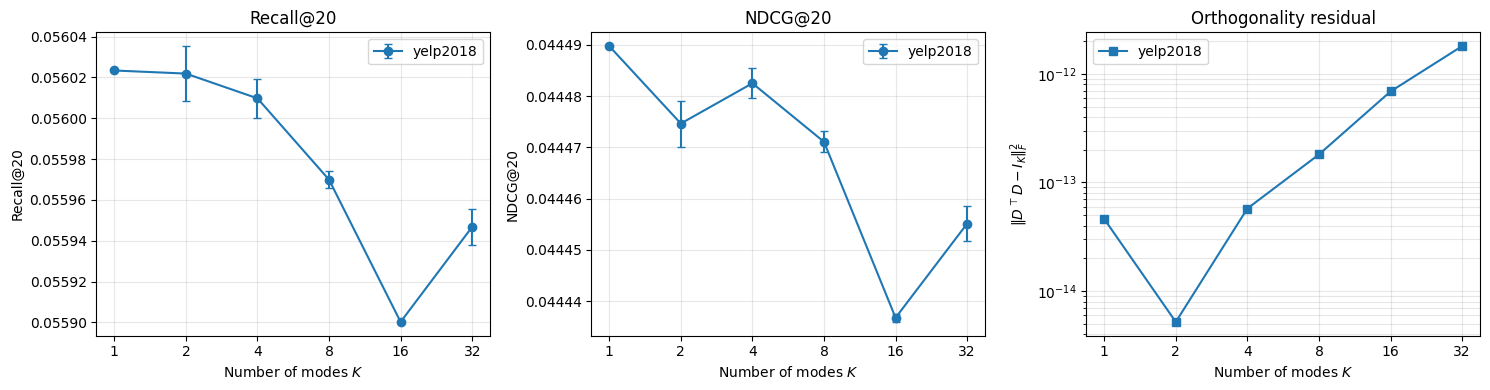

In [10]:
# ============================================================================
# CELL 9 — RQ2 FIGURE 1: Recall@20 / NDCG@20 vs K (one line per dataset)
#          + secondary panel: orthogonality residual vs K
# Reads every rq2_results_<dataset>.json in RQ2_DIRS, so run Cell 8 once per
# dataset (each notebook writes its own JSON), copy the JSONs into one folder,
# and re-run this cell only.
# ============================================================================
import glob, json, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

RQ2_DIRS = [OUT_ROOT]            # add other folders holding rq2_results_*.json
RELATIVE = False                 # True -> plot % change vs K=1 (datasets on one scale)
RES_FLOOR = 1e-16                # log-axis floor: float32 QR gives ~1e-13..1e-12, never exactly 0

files = sorted(f for d in RQ2_DIRS for f in glob.glob(os.path.join(d, 'rq2_results_*.json')))
assert files, 'no rq2_results_*.json found'
data = [json.load(open(f)) for f in files]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in [(axes[0], 'recall@20', 'Recall@20'), (axes[1], 'ndcg@20', 'NDCG@20')]:
    for r in data:
        ks = [k for k in r['k_grid'] if str(k) in r['results']]
        mu = np.array([np.mean(r['results'][str(k)][key]) for k in ks])
        sd = np.array([np.std(r['results'][str(k)][key]) for k in ks])
        if RELATIVE:
            sd, mu = 100 * sd / mu[0], 100 * (mu / mu[0] - 1)
        ax.errorbar(range(len(ks)), mu, yerr=sd, marker='o', capsize=3, label=r['dataset'])
    ax.set_xticks(range(len(ks))); ax.set_xticklabels(ks)
    ax.set_xlabel('Number of modes $K$')
    ax.set_ylabel(title + (' (% vs K=1)' if RELATIVE else ''))
    ax.set_title(title); ax.grid(alpha=.3); ax.legend()

ax = axes[2]
for r in data:
    ks = [k for k in r['k_grid'] if str(k) in r['results']]
    mu = np.array([np.mean(r['results'][str(k)]['ortho_res']) for k in ks])
    ax.plot(range(len(ks)), np.maximum(mu, RES_FLOOR), marker='s', label=r['dataset'])
ax.set_yscale('log'); ax.set_xticks(range(len(ks))); ax.set_xticklabels(ks)
ax.set_xlabel('Number of modes $K$')
ax.set_ylabel(r'$\|D^\top D - I_K\|_F^2$')
ax.set_title('Orthogonality residual'); ax.grid(alpha=.3, which='both'); ax.legend()

plt.tight_layout()
for ext in ('png', 'pdf'):
    out = os.path.join(OUT_ROOT, f'fig1_rq2.{ext}')
    plt.savefig(out, dpi=200, bbox_inches='tight')
print('saved', os.path.join(OUT_ROOT, 'fig1_rq2.{png,pdf}'))
plt.show()


In [11]:
# ============================================================================
# CELL 10 — RQ3: CONTRIBUTION OF BEHAVIOURAL GATING   (Table 4)
#
# Four variants at the best K from RQ2 (everything else identical, incl. the
# frozen backbone, Stage-III proxies, basis D, alpha, lambda_pop):
#   (a) Full model   : learned gate  g_v = softmax(W_v q_v + b_v)      [K = K*]
#   (b) Uniform gate : g_{v,k} = 1/K                                   [K = K*]
#   (c) Random gate  : g_v ~ Dirichlet(c * 1_K), drawn ONCE per node,
#                      then frozen (a fresh draw per seed)             [K = K*]
#   (d) No behaviour : K = 1, g_{v,1} = 1 (no gating at all)
#
# CONFOUND handled here: Cell 5 also has a behaviour-conditioned popularity
# offset  s(u,i) -= lambda_u(q_u) * rho_i.  lambda_u is a function of q_u, so in
# an "as-configured" run EVERY variant -- including (b), (c), (d) -- still uses
# behaviour through lambda_u, which shrinks the gate gaps. We therefore run two
# settings:
#   'as-configured' : offset on iff RQ2_OFFSET (what the full pipeline ships)
#   'gate-only'     : offset OFF in all variants -> the gate is the ONLY place
#                     behaviour enters. This is the clean test of the claim.
# Requires Cell 8 to have run (uses T_ALL, PRESENT, build_basis_K, run_bcps_basis).
# ============================================================================
import json

RQ3_DIRICHLET = 1.0       # concentration c of the symmetric Dirichlet (c=1: uniform over simplex)
RQ3_K         = None      # None -> best K (by mean NDCG@20) from this dataset's RQ2 results


class BCPSFixedGate(BCPS):
    """BCPS with node gates frozen to given (n_nodes, K) tables; nothing about the gate is learned."""
    def __init__(self, basis, n_proxies, alpha, g_u, g_i, score_offset):
        super().__init__(basis, n_proxies, alpha, gate_mode='random', score_offset=score_offset)
        self.register_buffer('g_u', g_u.float())
        self.register_buffer('g_i', g_i.float())

    def gates(self, qu, qi):
        assert qu.shape[0] == self.g_u.shape[0] and qi.shape[0] == self.g_i.shape[0]
        return self.g_u, self.g_i


def _pick_k():
    if RQ3_K is not None:
        return int(RQ3_K)
    ks = [k for k in rq2['k_grid'] if str(k) in rq2['results']]
    nd = {k: np.mean(rq2['results'][str(k)]['ndcg@20']) for k in ks}
    k_star = max(nd, key=nd.get)
    if k_star == 1:
        k_star = max((k for k in ks if k > 1), key=nd.get)
        print(f'[rq3] WARNING: RQ2 peaked at K=1 -> gating is vacuous there. '
              f'Using best K>1 = {k_star} instead; say so in the paper.')
    return k_star


def make_variant(name, K, alpha, off):
    """Return (K_used, factory) for one variant; factory(basis) builds the model."""
    n_p = len(PROXY_COLS)
    if name == 'Full model':
        return K, lambda b: BCPS(b, n_p, alpha, gate_mode='learned', score_offset=off)
    if name == 'Uniform gate':
        return K, lambda b: BCPS(b, n_p, alpha, gate_mode='uniform', score_offset=off)
    if name == 'Random gate':
        def f(b):
            dist = torch.distributions.Dirichlet(torch.full((K,), RQ3_DIRICHLET))
            return BCPSFixedGate(b, n_p, alpha, dist.sample((NUM_USERS,)),
                                 dist.sample((NUM_ITEMS,)), off)
        return K, f
    if name == 'No behavior (K=1)':
        return 1, lambda b: BCPS(b, n_p, alpha, gate_mode='uniform', score_offset=off)  # 1/1 = 1
    raise ValueError(name)


VARIANTS = ['Full model', 'Uniform gate', 'Random gate', 'No behavior (K=1)']
K_STAR   = _pick_k()
SETTINGS = {'as-configured': bool(RQ2_OFFSET), 'gate-only': False}
if not RQ2_OFFSET:
    SETTINGS.pop('gate-only')            # identical to as-configured; don't run twice
print(f'[rq3] dataset={DATASET_NAME}  K*={K_STAR}  alpha={RQ2_ALPHA}  lambda_pop={RQ2_LPOP}  '
      f'seeds={N_SEEDS}  settings={list(SETTINGS)}')

_basis_cache = {}
def _basis(K):
    if K not in _basis_cache:
        _basis_cache[K] = build_basis_K(T_ALL, PRESENT, K)[0]
    return _basis_cache[K]

RQ3_RESUME = True
_path3 = os.path.join(OUT_ROOT, f'rq3_results_{DATASET_NAME}.json')
rq3 = {'dataset': DATASET_NAME, 'k_star': K_STAR, 'n_seeds': N_SEEDS,
       'dirichlet_concentration': RQ3_DIRICHLET,
       'config': {'alpha': RQ2_ALPHA, 'lambda_pop': RQ2_LPOP},
       'baseline': rq2['baseline'], 'settings': {}}
_pull_from_inputs(f'rq3_results_{DATASET_NAME}.json')
if RQ3_RESUME and os.path.exists(_path3):
    _o = json.load(open(_path3))
    if all(_o.get(k) == rq3[k] for k in ('k_star', 'n_seeds', 'dirichlet_concentration', 'config')):
        rq3['settings'] = _o['settings']
        print('[rq3] resuming from existing results file')
    else:
        print('[rq3] existing results file has a different K*/config/seeds -> ignored')


def _dump3():
    with open(_path3, 'w') as fh:
        json.dump(rq3, fh, indent=1)

_rq3_t0, _vdurs, _rq3_incomplete = time.time(), [0.0], False
for sname, off in SETTINGS.items():
    if _rq3_incomplete:
        break
    print(f'\n=== setting: {sname}  (score_offset={off}) ===')
    print(f'{"variant":<20}{"K":>3}{"R@20":>18}{"N@20":>18}{"ARP@20":>9}{"gate_std":>10}')
    res = rq3['settings'].get(sname, {}).get('results', {})
    rq3['settings'][sname] = {'score_offset': bool(off), 'results': res}
    for vname in VARIANTS:
        tag = ''
        if vname in res:
            tag = '(cached)'
        else:
            if time.time() - _rq3_t0 + max(_vdurs) > RQ_TIME_BUDGET_H * 3600:
                _rq3_incomplete = True
                print(f'!!! RQ time budget reached before "{vname}" ({sname}). Results saved; attach this '
                      "notebook's output as an input in a new session and re-run this cell to finish.")
                break
            _tv = time.time()
            K_used, factory = make_variant(vname, K_STAR, RQ2_ALPHA, off)
            runs_v = [run_bcps_basis(_basis(K_used), SEED + s, RQ2_ALPHA, RQ2_LPOP, off,
                                     make_model=factory)[1] for s in range(N_SEEDS)]
            res[vname] = {'K': K_used,
                          'recall@20': [m[20]['recall'] for m in runs_v],
                          'ndcg@20':   [m[20]['ndcg'] for m in runs_v],
                          'arp@20':    [m[20]['arp'] for m in runs_v],
                          'gate_std':  [m['gate_std'] for m in runs_v]}
            _vdurs.append(time.time() - _tv)
            _dump3()                                   # checkpoint after every variant
        r, n = res[vname]['recall@20'], res[vname]['ndcg@20']
        print(f'{vname:<20}{res[vname]["K"]:>3}{np.mean(r):>11.4f}±{np.std(r):.4f}'
              f'{np.mean(n):>11.4f}±{np.std(n):.4f}{np.mean(res[vname]["arp@20"]):>9.4f}'
              f'{np.mean(res[vname]["gate_std"]):>10.4f} {tag}')

    if not all(v in res for v in VARIANTS):
        print('  (setting incomplete - interpretation skipped)')
        continue
    # ---- interpretation helpers (NDCG@20, paired by seed) ----
    nd = {v: np.array(res[v]['ndcg@20']) for v in VARIANTS}
    def gap(a, b):
        d = nd[a] - nd[b]
        return d.mean(), d.std()
    order = sorted(VARIANTS, key=lambda v: -nd[v].mean())
    print('  ranking by NDCG@20:', ' > '.join(order))
    print('  expected           : Full > Uniform > {Random, No behavior}')
    fu, ur, un = gap('Full model', 'Uniform gate'), gap('Uniform gate', 'Random gate'), \
                 gap('Uniform gate', 'No behavior (K=1)')
    print(f'  Full - Uniform     : {fu[0]:+.4f} (paired seed std {fu[1]:.4f})')
    print(f'  Uniform - Random   : {ur[0]:+.4f} (paired seed std {ur[1]:.4f})')
    print(f'  Uniform - NoBehav  : {un[0]:+.4f} (paired seed std {un[1]:.4f})')
    if abs(fu[0]) < max(fu[1], 1e-12) * 2:
        print('  NOTE: |Full-Uniform| < 2x seed std -> gap not resolvable; do not claim it either way.')

_dump3()
print(f'\n[rq3] saved -> {_path3}')
if 'gate-only' in SETTINGS and 'as-configured' in SETTINGS:
    print('[rq3] If Full-Uniform is larger in gate-only than as-configured, lambda_u(q_u) was '
          'absorbing part of the behavioural signal; report gate-only as the clean Table 4.')


# ---- TABLE 4: merges every rq3_results_<dataset>.json found --------------------
import glob
RQ3_DIRS = [OUT_ROOT]                    # add folders holding other datasets' JSONs
_files = sorted(f for d in RQ3_DIRS for f in glob.glob(os.path.join(d, 'rq3_results_*.json')))
_data = [json.load(open(f)) for f in _files]
_md, _tex = [], []
for sname in SETTINGS:
    ds = [r for r in _data if sname in r['settings']]
    hdr = '| Variant | ' + ' | '.join(f"{r['dataset']} (K*={r['k_star']})" for r in ds) + ' |'
    _md += [f'\n**Setting: {sname}**  (cells: Recall@20 / NDCG@20)\n', hdr,
            '|---|' + '---|' * len(ds)]
    _tex += [f'% setting: {sname}', r'\begin{tabular}{l' + 'c' * len(ds) + '}', r'\toprule',
             'Variant & ' + ' & '.join(r['dataset'] for r in ds) + r' \\ \midrule']
    for v in VARIANTS:
        cells = []
        for r in ds:
            x = r['settings'][sname]['results'].get(v)
            cells.append('n/a' if x is None else
                         f"{np.mean(x['recall@20']):.4f} / {np.mean(x['ndcg@20']):.4f}")
        _md.append(f'| {v} | ' + ' | '.join(cells) + ' |')
        _tex.append(v.replace('_', r'\_') + ' & ' + ' & '.join(cells) + r' \\')
    _tex += [r'\bottomrule', r'\end{tabular}', '']
_out = '\n'.join(_md)
print('\n' + _out)
open(os.path.join(OUT_ROOT, 'table4_rq3.md'), 'w').write(_out)
open(os.path.join(OUT_ROOT, 'table4_rq3.tex'), 'w').write('\n'.join(_tex))
print(f'\n[rq3] wrote table4_rq3.md / table4_rq3.tex to {OUT_ROOT}')


[rq3] WARNING: RQ2 peaked at K=1 -> gating is vacuous there. Using best K>1 = 4 instead; say so in the paper.
[rq3] dataset=yelp2018  K*=4  alpha=0.7  lambda_pop=1.0  seeds=3  settings=['as-configured']

=== setting: as-configured  (score_offset=False) ===
variant               K              R@20              N@20   ARP@20  gate_std
Full model            4     0.0560±0.0000     0.0445±0.0000   0.1419    0.0040 
Uniform gate          4     0.0544±0.0000     0.0432±0.0000   0.1535    0.0000 
Random gate           4     0.0543±0.0002     0.0431±0.0002   0.1535    0.1936 
No behavior (K=1)     1     0.0560±0.0000     0.0445±0.0000   0.1416    0.0000 
  ranking by NDCG@20: No behavior (K=1) > Full model > Uniform gate > Random gate
  expected           : Full > Uniform > {Random, No behavior}
  Full - Uniform     : +0.0013 (paired seed std 0.0000)
  Uniform - Random   : +0.0001 (paired seed std 0.0002)
  Uniform - NoBehav  : -0.0013 (paired seed std 0.0000)

[rq3] saved -> /kaggle/working/